<a href="https://colab.research.google.com/github/JihyunPark4n/thesis-ibl-behavioral-state-analysis/blob/main/thesis_behavioral_state_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Master's thesis analysis notebook.

Title: Identifying Latent Behavioral States in Mice Using Sliding-Window GLMs and Gaussian Mixture Models

This notebook contains the full analysis pipeline used for behavioral preprocessing, sliding-window GLM estimation, GMM-based state inference, and state-based behavioral characterization.



---


**Behavioral Data Acquisition and Preprocessing**

In [1]:
# @title
! pip install ONE-api
! pip install ibllib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 414.6/414.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.2 MB/s eta 0:00

In [2]:
# Import the ONE (Open Neurophysiology Environment) API factory from the ONE API package
from one.api import ONE

# Create an instance of the OneAlyx class, specifying the base URL of the server and a password for authentication
one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True)

In [3]:
import numpy as np
import pandas as pd
from one.api import ONE

one = ONE()  # Initialize IBL ONE API

# List of subjects from the Witten lab dataset
subjects = [
    'ibl_witten_04', 'ibl_witten_05', 'ibl_witten_06', 'ibl_witten_07',
    'ibl_witten_11', 'ibl_witten_12', 'ibl_witten_13', 'ibl_witten_14',
    'ibl_witten_15', 'ibl_witten_16', 'ibl_witten_17', 'ibl_witten_18',
    'ibl_witten_19', 'ibl_witten_20', 'ibl_witten_21', 'ibl_witten_22',
    'ibl_witten_23', 'ibl_witten_24', 'ibl_witten_25', 'ibl_witten_26',
    'ibl_witten_27', 'ibl_witten_29', 'ibl_witten_32',
    'fip_13', 'fip_14', 'fip_15', 'fip_16', 'fip_26', 'fip_27', 'fip_28',
    'fip_29', 'fip_30', 'fip_31', 'fip_32', 'fip_33', 'fip_34', 'fip_35',
    'fip_36', 'fip_37', 'fip_38', 'fip_39', 'fip_40', 'fip_41', 'fip_42',
    'fip_43', 'fip_901', 'fip_902', 'fip_903', 'fip_904', 'fip_905',
    'fip_906', 'fip_907', 'fip_908', 'fip_910', 'fip_911', 'fip_912',
    'fip_913', 'fip_914'
]

# Cannonical block probabilities used in the IBL task
CANON = np.array([0.2, 0.5, 0.8]) # Block probabilities should be among 0.2, 0.5, 0.8

def is_biased_block_session(prob, tol=1e-6):
    """Determine if probabilityLeft is a session consisting only of {0.2,0.5,0.8}
    """
    prob = np.asarray(prob, dtype=float)
    prob = prob[np.isfinite(prob)] # Remove NaNs

    if prob.size == 0:
        return False

    u = np.unique(np.round(prob, 6)) # Extract unique values (rounded for numerical stability)

    # False if the value is other than 0.2, 0.5, 0.8
    return set(np.round(u, 2)).issubset(set(CANON))

# Storage containers
all_data = []
kept_sessions = 0
skipped_sessions = 0
skipped_info = []

# Iterate over all subjects and sessions
for subject in subjects:
    eids = one.search(subject=subject)
    for eid in eids:
        try:
            tr = one.load_object(eid, "trials")  # Load trial-level behavioral data

            probabilityLeft = tr["probabilityLeft"]
            # Filter out sessions with non-canonical block structures
            if not is_biased_block_session(probabilityLeft):
              skipped_sessions += 1
              prob = np.asarray(probabilityLeft, dtype=float)
              prob = prob[np.isfinite(prob)]
              u = np.unique(np.round(prob, 6))
              u_round2 = np.unique(np.round(u, 2))

              # Values ​​that are not in canonical
              non_canon = sorted(set(u_round2) - set(CANON))

              skipped_info.append({
                  "subject": subject,
                  "session": str(eid),
                  "unique_prob_round6": u.tolist(),
                  "unique_prob_round2": u_round2.tolist(),
                  "non_canonical": non_canon,
                  "n_unique": len(u_round2),
              })
              continue

            kept_sessions += 1

            choice = tr["choice"]   # IBL data: -1 (right)/ +1 (left)
            feedback = tr["feedbackType"]
            contrastLeft = np.nan_to_num(tr["contrastLeft"], nan=0.0)  # Replace NaNs in contrast with 0 to calculate signed_contrast (NaN: no stimulus on that side)
            contrastRight = np.nan_to_num(tr["contrastRight"], nan=0.0)
            response_times = tr["response_times"]   # Movement completion
            goCue_times = tr["goCue_times"]   # Go cue onset

            reaction_times = response_times - goCue_times  # Compute reaction times
            correct = (feedback == 1).astype(int)   # 1 is corrct (rewarded)
            signed_contrast = contrastRight - contrastLeft  # Positive: contrast Right, Negative: contrast Left
            n_trials = len(choice)

            # Convert probabilityLeft to numpy array
            p = np.asarray(probabilityLeft, dtype=float)

            #Construct trial-pair dataset with previous and current trials
            for t in range(1, n_trials):
                if (
                    np.isnan(reaction_times[t]) or   # Skip trials with missing values in relevant variables
                    np.isnan(choice[t]) or
                    np.isnan(correct[t]) or
                    np.isnan(choice[t-1]) or
                    np.isnan(correct[t-1]) or
                    np.isnan(p[t]) or
                    np.isnan(p[t-1])
                ):
                    continue

                all_data.append({
                    "subject": subject,
                    "session": str(eid),
                    "trial_index": t,

                    # Previous trial values
                    "prev_correct": correct[t-1],
                    "prev_choice": choice[t-1],
                    "prev_feedbackType": feedback[t-1],
                    "prev_reaction_time": reaction_times[t-1],
                    "prev_signed_contrast": signed_contrast[t-1],
                    "probabilityLeft_prev": p[t-1],

                    # Current trial values
                    "current_correct": correct[t],
                    "current_choice": choice[t],
                    "current_feedbackType": feedback[t],
                    "current_reaction_time": reaction_times[t],
                    "current_signed_contrast": signed_contrast[t],
                    "current_probabilityLeft": p[t],
                })

        except Exception as e:
            skipped_sessions += 1   # Skip sessions that fail to load
            continue

# Convert collected data into Dataframes
skipped_df = pd.DataFrame(skipped_info)
beh_df = pd.DataFrame(all_data)

# Summary statistics
print("kept_sessions:", kept_sessions, "skipped_sessions:", skipped_sessions)

Streaming output truncated to the last 5000 lines.
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/wittenlab/Subjects/ibl_witten_15/2019-09-13/001/alf/_ibl_trials.table.pqt: 100%|██████████| 75.0k/75.0k [00:00<00:00, 401kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/wittenlab/Subjects/ibl_witten_15/2019-09-12/001/alf/_ibl_trials.repNum.npy: 100%|██████████| 7.47k/7.47k [00:00<00:00, 52.2kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/wittenlab/Subjects/ibl_witten_15/2019-09-12/001/alf/_ibl_trials.table.pqt: 100%|██████████| 66.7k/66.7k [00:00<00:00, 284kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/wittenlab/Subjects/ibl_witten_15/2019-09-11/001/alf/_ibl_trials.repNum.npy: 100%|██████████| 7.78k/7.78k [00:00<00:00, 52.8kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/wittenlab/Subjects/ibl_witten_15/2019-09-11/001/alf/_ibl_trials.table.pqt: 100%|██████████| 69.6k/69.6k [00:00<00:00, 611kB/s]
(S3) /root

kept_sessions: 1397 skipped_sessions: 218


In [4]:
# Filter problematic trials with non-positive reaction time or NaN values
glm_df = beh_df[
    (beh_df["current_reaction_time"] > 0) &
    (beh_df["prev_reaction_time"] > 0)
].copy()  # Exclude trials with non-positive reaction time

glm_df = glm_df.dropna()  # Exclude trials with NaN values

glm_df["subject"] = glm_df["subject"].astype(str)
glm_df["session"] = glm_df["session"].astype(str)

glm_df = glm_df.sort_values(["subject", "session", "trial_index"]).reset_index(drop=True)



---

**Sliding-Window GLM**

Weight Estimation

In [5]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.container import BarContainer

In [6]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9
})

In [7]:
def compute_window_weights(
    win: pd.DataFrame,
    min_trials: int = 5,
    use_global_prev: bool = False,
    global_prev_choice_col: str = "prev_choice_signed_global",
    global_prev_fb_col: str = "prev_feedbackType_global",
) -> dict:
    """
    Estimate sliding-window GLM weights using a logistic regression within a sliding window
    """

    feats = {
        "w_stim": np.nan,
        "w_prevChoice": np.nan,
        "w_wsls": np.nan,
        "w_bias": np.nan,
        "n_trials_used": 0,
    }

    if len(win) < min_trials:
        feats["n_trials_used"] = len(win)
        return feats

    # Sort by trial_index
    w = win.sort_values("trial_index").reset_index(drop=True).copy()

    # choice_signed: +1 (right)/ -1 (left) to compare easily with signed_contrast
    if "choice_signed" not in w.columns:
        w["choice_signed"] = -w["current_choice"]
        w.loc[w["current_choice"] == 0, "choice_signed"] = np.nan  # 0 (no choice): nan

    # signed_contrast
    if "signed_contrast" not in w.columns:   # Positive (right)/ Negative (left)
        w["signed_contrast"] = w["current_signed_contrast"]

    # prev processing
    if use_global_prev and global_prev_choice_col in w.columns and global_prev_fb_col in w.columns:
        w["prev_choice_signed_eff"] = w[global_prev_choice_col]
        w["prev_feedbackType_eff"] = w[global_prev_fb_col]
    else:
        if "prev_choice_signed" not in w.columns and "prev_choice" in w.columns:   # Prev_choice_signed: +1 (right)/ -1 (left)
            w["prev_choice_signed"] = -w["prev_choice"]

        w["prev_choice_signed_eff"] = w.get("prev_choice_signed")
        w["prev_feedbackType_eff"] = w.get("prev_feedbackType")

    required_cols = [
        "choice_signed",
        "signed_contrast",
        "prev_choice_signed_eff",
        "prev_feedbackType_eff",
    ]
    if not all(col in w.columns for col in required_cols):
        feats["n_trials_used"] = len(w)
        return feats

    sub = w[required_cols].dropna()
    feats["n_trials_used"] = len(sub)

    if len(sub) < min_trials:
        return feats

# Model: logit P(y=1) = w_stim * x_stim + w_prevChoice * x_prevChoice + w_wsls * (prevChoice * prevFeedback) + w_bias
    y = (sub["choice_signed"] == 1).astype(int).values  # Binary target: 1 = right choice, 0 = left choice

    X = np.column_stack([   # Design matrix
            sub["signed_contrast"].values,
            sub["prev_choice_signed_eff"].values,
            (sub["prev_choice_signed_eff"] * sub["prev_feedbackType_eff"]).values,
            np.ones(len(sub)),
        ])

    try:
        lr = LogisticRegression(fit_intercept=False, max_iter=500)   # Fit logistic regression
        lr.fit(X, y)
        w_hat = lr.coef_[0]   # Extract weights corresponding to each regressor
        feats.update({
                "w_stim": float(w_hat[0]),    # Stimulus sensitivity weight
                "w_prevChoice": float(w_hat[1]),    # Previous-choice weight
                "w_wsls": float(w_hat[2]),    # Win-stay/lose-switch weight
                "w_bias": float(w_hat[3]),    # Bias term
            })
    except Exception:
        pass

    return feats

In [8]:
def build_windows_for_session_trial_index(
    block,
    window_size=20,   # Window size
    step=10,           # Step size
    min_trials=1
):
    """
    Build sliding windows for a session and estimate GLM weights in each window
    """
    rows = []
    block = block.sort_values("trial_index").reset_index(drop=True)

    tmin = int(block["trial_index"].min())
    tmax = int(block["trial_index"].max())

    # sliding based on trial_index
    for s in np.arange(tmin, tmax +1, step):
        e = s + window_size

        # trial_index range mask
        win = block[(block["trial_index"] >= s) &
                    (block["trial_index"] <  e)].copy()

        feats = compute_window_weights(win, min_trials=min_trials)

        feats.update({
            "subject": block["subject"].iloc[0],
            "session": block["session"].iloc[0],
            "win_start": int(s),
            "win_end": int(e),
            "win_anchor": int(s + window_size // 2),  # The center of each window
            "window_type": "window",
        })
        rows.append(feats)

    return pd.DataFrame(rows)

def build_windows_all_trial_index(
    beh_df,
    window_size=20,
    step=10,
    min_trials=1
):
    """
    Build sliding windows for all subjects and sessions
    """
    all_rows = []
    for (subj, sess), block in beh_df.groupby(["subject","session"], sort=False):
        all_rows.append(
            build_windows_for_session_trial_index(
                block,
                window_size=window_size,
                step=step,
                min_trials=min_trials
            ))
    win_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    return win_df



---

Window Size Selection

In [9]:
window_sizes = [10, 20, 30, 40, 50]
all_win_list = []

for W in window_sizes:
    win_df = build_windows_all_trial_index(
        glm_df,
        window_size=W,
        step= W//2,     # 50% overlapping
        min_trials=1,
    )
    if win_df.empty:
        print(f"window_size={W}: There is no valid window.")
        continue
    win_df["window_size"] = W
    all_win_list.append(win_df)

if len(all_win_list) == 0:
    raise ValueError("No valid window at any window size.")

weights_df = pd.concat(all_win_list, ignore_index=True)

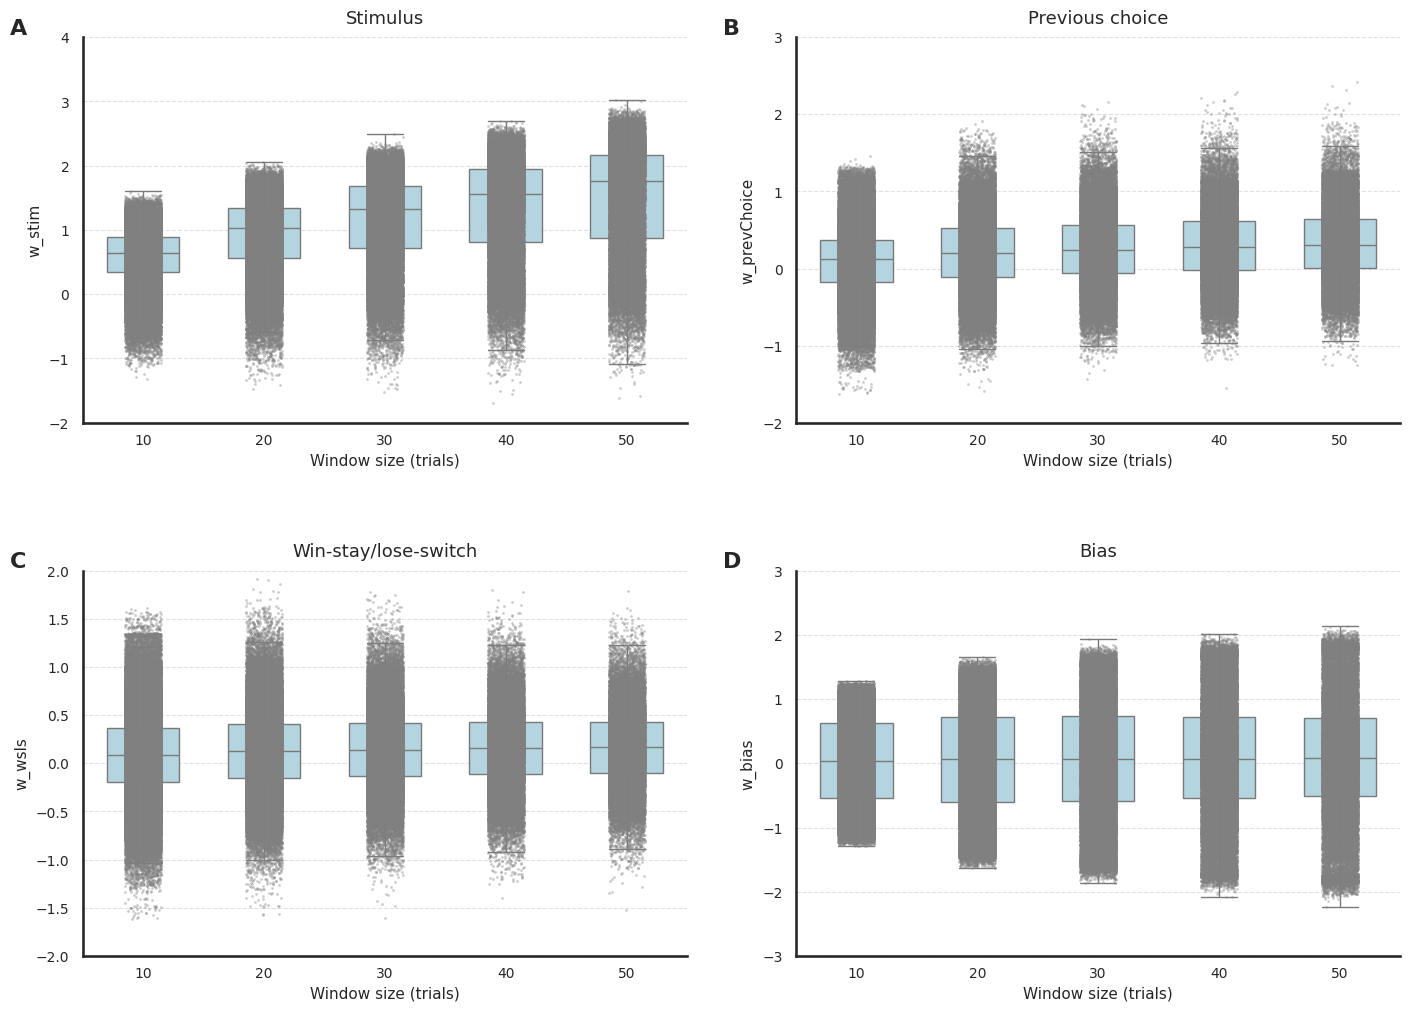

In [10]:
# Figure 1

# List of weight columns to analyze
weight_cols = [c for c in ["w_stim", "w_prevChoice", "w_wsls", "w_bias"]
               if c in weights_df.columns]

# Panel titles
panel_titles = {
    "w_stim": "Stimulus",
    "w_prevChoice": "Previous choice",
    "w_wsls": "Win-stay/lose-switch",
    "w_bias": "Bias",
}

# global style
sns.set_context("talk", font_scale=1.1)
sns.set_style("white")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.15, wspace=0.05)
axes = np.array(axes).reshape(-1)

labels = ["A", "B", "C", "D"]

def choose_tick_step(ymin, ymax):
    rng = float(ymax - ymin)
    return 0.5 if rng <= 4 else 1.0

for i, (ax, wcol) in enumerate(zip(axes, weight_cols)):
    sub = weights_df[["window_size", wcol]].dropna()
    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub, x="window_size", y=wcol,
        color="lightblue", width=0.6,
        fliersize=0, ax=ax
    )
    sns.stripplot(
        data=sub, x="window_size", y=wcol,
        color="gray", size=2, alpha=0.4,
        jitter=0.15, ax=ax
    )

    # panel label
    ax.text(-0.12, 1.05, labels[i],
            transform=ax.transAxes,
            fontsize=16, fontweight="bold",
            va="top")

    # y ticks + aligned ylim
    ymin, ymax = sub[wcol].min(), sub[wcol].max()
    step = choose_tick_step(ymin, ymax)

    ylow  = np.floor(ymin / step) * step
    yhigh = np.ceil(ymax / step) * step
    ax.set_ylim(ylow, yhigh)
    ax.yaxis.set_major_locator(MultipleLocator(step))

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, which="major",
                  linestyle="--", linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(False)

    ax.tick_params(axis="y", which="major", direction="out", length=6, width=1.2)
    ax.tick_params(axis="x", which="major", direction="out", length=4, width=1.0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # labels
    ax.set_title(panel_titles.get(wcol, wcol), fontsize=13, pad=10)
    ax.set_xlabel("Window size (trials)", fontsize=11)
    ax.set_ylabel(wcol, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)

# unused axes off
for j in range(len(weight_cols), 4):
    axes[j].set_axis_off()

plt.show()

In [11]:
def count_raw_trials_per_window(beh_df, window_size=20, step=10):
    """
    Compute the number of raw trials cintained in each sliding window
    """
    rows = []

    # Iterate over each subject-session pair
    for (subj, sess), block in beh_df.groupby(["subject", "session"], sort=False):
        block = block.sort_values("trial_index").reset_index(drop=True)   # Sort trials in temporal order

        if block.empty:   # Skip if no data
            continue

        tmin = int(block["trial_index"].min())  # Define the range of trial indices for this session
        tmax = int(block["trial_index"].max())
        starts = np.arange(tmin, tmax + 1, step) # Generate window start positions

        for s in starts:    # Sliding window
            e = s + window_size   # Window end
            win = block[(block["trial_index"] >= s) & (block["trial_index"] < e)].copy()   # Select trials within the current windows

            rows.append({
                "subject": subj,
                "session": sess,
                "win_start": s,
                "win_end": e,
                "n_raw_trials": len(win),   # Number of trials in this window
            })

    return pd.DataFrame(rows)

# Compute raw trial counts per window
raw_count_df = count_raw_trials_per_window(glm_df, window_size=20, step=10)

# Summarize distribution of trial across all windows
print(raw_count_df["n_raw_trials"].describe())

count    99060.000000
mean        19.693711
std          1.897067
min          1.000000
25%         20.000000
50%         20.000000
75%         20.000000
max         20.000000
Name: n_raw_trials, dtype: float64


In [12]:
def build_fullweights_all(beh_df, min_trials=1):
    """
    Compute full-session GLM weights
    For each subject and session, all trials are used as a single window to estimate logistic regression weights.
    These full-session weights are used to compare with sliding-window estimates.
    """
    rows = []
    for (subj, sess), block in beh_df.groupby(["subject","session"], sort=False):  # For all subject-session pair
        block = block.sort_values("trial_index").reset_index(drop=True)  # Ensure trials are ordered
        feats = compute_window_weights(block, min_trials=min_trials)    # Fit GLM using all trials in the session (full window)

        start = int(block["trial_index"].min())  # Starting point of window
        end   = int(block["trial_index"].max())  # End point of window
        anchor = int((start + end) / 2)          # Window anchor (midpoint)

        feats.update({
            "subject": subj,
            "session": sess,
            "win_start": start,
            "win_end": end,
            "win_anchor": anchor,
            "window_type": "full", # full-session estimate
        })
        rows.append(feats)

    return pd.DataFrame(rows)

def prepare_window_vs_full_merged(
    window_df,
    full_df,
    weight_cols=("w_stim", "w_prevChoice", "w_wsls", "w_bias"),
    min_windows_per_session=1,
):
    """
    Prepare a merged session-level comparing: mean sliding-window weights, full-session weights per session
    """
    base_keys = ["subject", "session"]

    w = window_df.copy()
    f = full_df.copy()

    for df in (w, f):
        for col in base_keys:
            df[col] = df[col].astype(str).str.strip()

    weight_cols = [c for c in weight_cols if c in w.columns and c in f.columns]
    if len(weight_cols) == 0:
        raise ValueError("No common weight columns found.")

    w_agg = (       # Session-level mean of window weights
        w.groupby(base_keys)[weight_cols]
         .mean()
         .reset_index()
         .rename(columns={c: f"{c}_winMean" for c in weight_cols})
    )

    if min_windows_per_session > 1: # If necessary, filtering by mininmum number of windows
        nwin = w.groupby(base_keys).size().reset_index(name="n_win")
        w_agg = w_agg.merge(nwin, on=base_keys, how="left")
        w_agg = w_agg[w_agg["n_win"] >= min_windows_per_session].copy()

    f_only = (    # full-session weights
        f[base_keys + weight_cols]
        .rename(columns={c: f"{c}_full" for c in weight_cols})
    )

    merged = w_agg.merge(f_only, on=base_keys, how="inner")
    return merged

In [13]:
# Sliding-windows GLM estimates
win_df = build_windows_all_trial_index(
    glm_df,
    window_size=20,   # Window size = 20 trials
    step=10,          # Step size = 10 trials (50% overlapping)
    min_trials=1,
)

# full-session GLM estimates
full_df = build_fullweights_all(
    glm_df,
    min_trials=1,
)

# Prepare merged session-level table for comparing
# mean sliding-window weights with full-session weights
merged_AB = prepare_window_vs_full_merged(
    win_df,
    full_df,
    weight_cols=("w_stim", "w_prevChoice", "w_wsls", "w_bias"),
    min_windows_per_session=1,
)

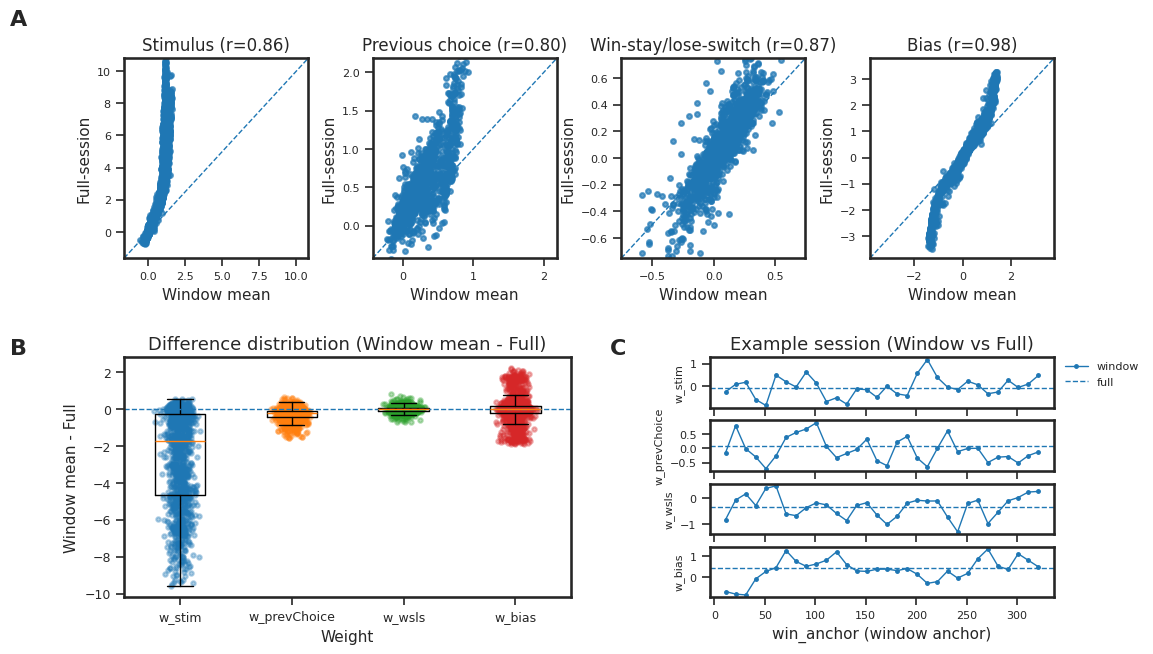

Example session for Panel C caption:
Subject: fip_911
Session: 94291474-f8ac-42b6-8951-9bf3028c4a37


In [14]:
# Figure 2

# Tick style function: standardize axis tick appearance
def make_ticks_visible(ax, labelsize=8, length=6, width=1.2, direction="out"):
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=labelsize,
        length=length,
        width=width,
        direction=direction,
        bottom=True, left=True,
        top=False, right=False
    )

# Panel A: scatter plots (window mean vs full-session weights)
def get_axis_limits(x, y, lower=1, upper=99, pad=0.15):
    """
    Compute axis limits from percentiles of the combined x and y values (1-99% range of the data)
    All points remain in the scatter, but the visible axis range is restricted
    """
    # percentile based
    lo = np.percentile(np.concatenate([x, y]), lower)
    hi = np.percentile(np.concatenate([x, y]), upper)

    rng = hi - lo
    if rng == 0:
        rng = 1.0

    lo -= pad * rng
    hi += pad * rng

    return lo, hi

def plot_panel_A_style(
    axs,
    merged_AB,
    weight_cols,
    point_alpha=0.7,
    point_size=12,
    axis_percentiles=(1, 99),
    axis_pad=0.12,
):
    """
    scatter plots comparing session-level mean window weights with full-session weights
    """
    for ax, wc in zip(axs, weight_cols):
        x = merged_AB[f"{wc}_winMean"].to_numpy(float)
        y = merged_AB[f"{wc}_full"].to_numpy(float)

        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]
        y = y[m]

        if len(x) == 0:
            ax.set_axis_off()
            continue

        r = np.corrcoef(x, y)[0, 1] if len(x) >= 2 else np.nan     # Pearson correlation

        # scatter plot of all points
        ax.scatter(x, y, s=point_size, alpha=point_alpha)

        # restrict visible axis range, but keep all points in computation and plotting
        lo, hi = get_axis_limits(
            x, y,
            lower=axis_percentiles[0],
            upper=axis_percentiles[1],
            pad=axis_pad
        )

        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)  # identity line
        ax.set_xlim(lo, hi) #set axis limits
        ax.set_ylim(lo, hi)

        ax.set_title(f"{panel_titles.get(wc, wc)} (r={r:.2f})", fontsize=12)
        ax.set_xlabel("Window mean", fontsize=11)
        ax.set_ylabel("Full-session", fontsize=11)

        ax.grid(False)
        make_ticks_visible(ax, labelsize=8, length=6, width=1.2)

    # hide unused axes if any
    for ax in axs[len(weight_cols):]:
        ax.set_axis_off()

# Panel B: difference distribution
def plot_panel_B_style(ax, merged_AB, weight_cols, colors=None, seed=0):
    """
    Distribution of differences between window mean and full-session weights
    """

    if colors is None:
        colors = ["C0", "C1", "C2", "C3"]

    diffs = []
    for wc in weight_cols:
        d = (merged_AB[f"{wc}_winMean"] - merged_AB[f"{wc}_full"]).to_numpy(float)
        diffs.append(d[np.isfinite(d)])

    ax.boxplot(diffs, tick_labels=weight_cols, showfliers=False, patch_artist=False)  # Boxplot

    rng = np.random.default_rng(seed)  # Scatter points
    for i, arr in enumerate(diffs, start=1):
        if len(arr) == 0:
            continue
        xj = rng.normal(loc=i, scale=0.06, size=len(arr))
        ax.scatter(xj, arr, s=10, alpha=0.35, color=colors[i - 1])

    ax.axhline(0, linestyle="--", linewidth=1)    # Reference line at zero difference

    ax.set_title("Difference distribution (Window mean - Full)", fontsize=13)
    ax.set_xlabel("Weight", fontsize=11)
    ax.set_ylabel("Window mean - Full", fontsize=11)

    ax.grid(False)
    make_ticks_visible(ax, labelsize=9, length=6, width=1.2)

# Panel C: example session
def plot_panel_C_style(
    axs,
    win_df,
    full_df,
    subject,
    session,
    weight_cols=("w_stim", "w_prevChoice", "w_wsls", "w_bias"),
    x_col="win_anchor",
):
    """
    Time course of window-based weights within a single example session
    """
    w = win_df.copy()
    f = full_df.copy()
    for df in (w, f):    # consistent dtype
        df["subject"] = df["subject"].astype(str).str.strip()
        df["session"] = df["session"].astype(str).str.strip()

    # select one session
    w_s = w[(w["subject"] == str(subject)) & (w["session"] == str(session))].copy()
    f_s = f[(f["subject"] == str(subject)) & (f["session"] == str(session))].copy()

    if w_s.empty or f_s.empty:  # handle missing data
        for ax in axs:
            ax.set_axis_off()
        axs[0].text(
            0.5, 0.5, "No example data",
            ha="center", va="center", transform=axs[0].transAxes
        )
        return

    if x_col not in w_s.columns:    # X-axis
        for cand in ["win_start", "trial_index"]:
            if cand in w_s.columns:
                x_col = cand
                break
        if x_col not in w_s.columns:
            w_s["__x"] = np.arange(len(w_s))
            x_col = "__x"

    # title
    axs[0].set_title("Example session (Window vs Full)", fontsize=13)

    for ax, wc in zip(axs, weight_cols):
        if wc not in w_s.columns or wc not in f_s.columns:
            ax.set_axis_off()
            continue

        tmp = w_s[[x_col, wc]].copy()   # Clean and sort data
        tmp[x_col] = pd.to_numeric(tmp[x_col], errors="coerce")
        tmp[wc] = pd.to_numeric(tmp[wc], errors="coerce")
        tmp = tmp.dropna(subset=[x_col, wc]).sort_values(x_col)

        if tmp.empty:
            ax.set_axis_off()
            continue

        ax.plot(    # window trajectory
            tmp[x_col],
            tmp[wc],
            marker="o",
            markersize=2.5,
            linewidth=1,
            label="window"
        )

        y_full = pd.to_numeric(f_s[wc].iloc[0], errors="coerce")    # full-session reference line
        if np.isfinite(y_full):
            ax.axhline(float(y_full), linestyle="--", linewidth=1, label="full")

        ax.set_ylabel(wc, fontsize=8)
        ax.grid(False)
        make_ticks_visible(ax, labelsize=8, length=6, width=1.2)

    axs[-1].set_xlabel(   # x-axis label
        f"{x_col} (window anchor)" if x_col == "win_anchor" else x_col,
        fontsize=11
    )

    handles, labels = axs[0].get_legend_handles_labels()    # Legend
    if handles:
        axs[0].legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            frameon=False,
            fontsize=8,
            borderaxespad=0
        )

# Full figure assembly: A,B,C
def make_figure_ABC_styled(
    win_df,
    full_df,
    merged_AB,
    weight_cols=("w_stim", "w_prevChoice", "w_wsls", "w_bias"),
    example_subject=None,
    example_session=None,
    seed_example=7,
):
    """
    Assemble the full figure
    """
    weight_cols = [
        wc for wc in weight_cols
        if f"{wc}_winMean" in merged_AB.columns and f"{wc}_full" in merged_AB.columns
    ]

    if example_subject is None or example_session is None:
        ex = merged_AB.sample(1, random_state=seed_example)[["subject", "session"]].iloc[0]
        example_subject, example_session = ex["subject"], ex["session"]

    # Figure layout
    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[1.0, 1.2],
        width_ratios=[1.3, 1.0],
        wspace=0.35, hspace=0.45
    )

    # A: top
    gsA = gs[0, :].subgridspec(1, 4, wspace=0.35)
    axA = [fig.add_subplot(gsA[0, i]) for i in range(4)]
    plot_panel_A_style(axA, merged_AB, weight_cols)

    # B: bottom-left
    axB = fig.add_subplot(gs[1, 0])
    plot_panel_B_style(axB, merged_AB, weight_cols, colors=["C0", "C1", "C2", "C3"], seed=0)

    # C: bottom-right
    gsC = gs[1, 1].subgridspec(4, 1, hspace=0.25)
    axC = [fig.add_subplot(gsC[i, 0]) for i in range(4)]
    plot_panel_C_style(
        axC,
        win_df,
        full_df,
        example_subject,
        example_session,
        weight_cols=tuple(weight_cols),
        x_col="win_anchor",
    )

    # panel letters
    fig.text(0.03, 0.95, "A", fontsize=16, fontweight="bold", va="top")
    fig.text(0.03, 0.48, "B", fontsize=16, fontweight="bold", va="top")
    fig.text(0.53, 0.48, "C", fontsize=16, fontweight="bold", va="top")

    return fig, example_subject, example_session

# Run figure
plt.close("all")

fig, ex_subj, ex_sess = make_figure_ABC_styled(
    win_df=win_df,
    full_df=full_df,
    merged_AB=merged_AB,
    weight_cols=("w_stim", "w_prevChoice", "w_wsls", "w_bias"),
)

plt.show()
plt.close(fig)

# Print example suject and session name for Panel C
print("Example session for Panel C caption:")
print(f"Subject: {ex_subj}")
print(f"Session: {ex_sess}")



---

**Alignment of Esimtated Weights with Task Structure**

Bias Weights and Block Prior

In [15]:
# dtype Unification
for df in [glm_df, win_df]:
    df["session"] = df["session"].astype(str).str.strip()
    df["subject"] = df["subject"].astype(str).str.strip()

feature_cols = ["w_stim",  "w_bias", "w_prevChoice", "w_wsls"]

# window_size filter
WIN_SIZE = 20
if "window_size" in win_df.columns:
    win_df_use = win_df.query("window_type == 'window' and window_size == @WIN_SIZE").copy()
else:
    win_df_use = win_df.copy()

# Sort
sort_cols = ["subject","session"]
if "win_anchor" in win_df_use.columns:
    sort_cols.append("win_anchor")
win_df_use = win_df_use.sort_values(sort_cols).reset_index(drop=True)

# Exclude NaN
win_df_valid = win_df_use.dropna(subset=feature_cols).copy()

# coverage check: windows vs trials
pairs_win = win_df_use[["subject", "session"]].drop_duplicates()
pairs_trials = glm_df[["subject", "session"]].drop_duplicates()

pairs_win["in_windows"] = True
pairs_trials["in_trials"] = True

In [16]:
BLOCK_COL = "current_probabilityLeft"  # Column in glm_df that contains block prior (Probability of left stimulus)

glm = glm_df.copy()   # Make copies to avoid modifying original Dataframes
win = win_df_valid.copy()

glm["session"] = glm["session"].astype(str)  # Ensure session identifiers are strings
win["session"] = win["session"].astype(str)

rows = []
for (subj, ses), g_trials in glm.groupby(["subject", "session"], sort=False):  # Iterate over each subject-session
    g_win = win[(win["subject"] == subj) & (win["session"] == ses)] # Select corresponding windows for the same subject-session
    if g_win.empty:
        continue

    t = g_trials["trial_index"].to_numpy(int) # Extract trial indices and block prior values
    p = g_trials[BLOCK_COL].to_numpy(float)  # already {0.2,0.5,0.8}

    for _, w in g_win.iterrows(): # Iterate over each window
        lo = int(w["win_start"])
        hi = int(w["win_end"])

        m = (t >= lo) & (t < hi)  # win_end exclusive
        if not m.any():
            continue

        pw = p[m]  # Block prior values within the current window

        rows.append({  # Compute fraction of trials belonging to each block type
            "subject": subj,
            "session": ses,
            "win_start": lo,
            "win_end": hi,
            "n_trials_in_win": int(m.sum()),    # Number of trials
            "frac_02": float(np.mean(pw == 0.2)), # Right-biased block
            "frac_05": float(np.mean(pw == 0.5)), # Center
            "frac_08": float(np.mean(pw == 0.8)), # Left-biased block
        })

pur = pd.DataFrame(rows)    # Convert results to Dataframe

# Purity: maximum fraction among the block types within a window
pur["purity"] = pur[["frac_02","frac_05","frac_08"]].max(axis=1)

pur["majority_pLeft"] = (   # Determine the majority block type
    pur[["frac_02","frac_05","frac_08"]]
    .idxmax(axis=1)
    .map({"frac_02": 0.2, "frac_05": 0.5, "frac_08": 0.8})
)

pur["majority_block_type"] = pur["majority_pLeft"].map(   #Map block probabilities to categorical labels
    {0.2: "right80", 0.5: "center50", 0.8: "left80"}
)

# merge purity back to window-level dataframe
win2 = win.merge(
    pur,
    on=["subject", "session", "win_start", "win_end"],
    how="left",
    validate="one_to_one"   # ensures each window matches one purity
)

# keep only windows that successfully matched trials
win2 = win2.dropna(subset=["purity", "majority_pLeft"]).copy()

PURE_TH = 1.0
pure_win = win2.query("purity == @PURE_TH").copy()

# summary
n_all = len(win2)
n_pure = len(pure_win)

In [17]:
# Statistical tests: Permutation
def perm_corr_within_cluster(
    df: pd.DataFrame,
    cluster_cols: tuple[str, ...] = ("subject", "session"),
    x_col: str = "x",
    y_col: str = "y",
    shuffle_target: str = "x",
    n_perm: int = 10000,
    seed: int = 0,
) -> dict:
    """
    Compute a Pearson correlation between x and y and test significance using within-cluster permutation.
    Within each cluster, either x or y is shuffled while the other variable is kept fixed.
    """
    rng = np.random.default_rng(seed)   # Initialize random number generator

    d = df[list(cluster_cols) + [x_col, y_col]].dropna().copy()   # Select relevant columns and drop missing values
    if d.empty:
        raise ValueError("No valid rows after dropna().")

    d["__cluster__"] = d[list(cluster_cols)].astype(str).agg("||".join, axis=1)   # Create a cluster identifier
    clusters = d["__cluster__"].unique()  # Extract the clusters and group data by cluster
    by_cluster = {c: d[d["__cluster__"] == c] for c in clusters}

    def _corr(a, b):
        """
        Compute Pearson correlation between two arrays
        """
        a = np.asarray(a, float)
        b = np.asarray(b, float)
        if np.nanstd(a) == 0 or np.nanstd(b) == 0:
            return np.nan
        return float(np.corrcoef(a, b)[0, 1])

    r_obs = _corr(d[x_col].to_numpy(), d[y_col].to_numpy()) # Compute observed correlation

    shuffle_target = shuffle_target.lower() # Validate shuffle target
    if shuffle_target not in {"x", "y"}:
        raise ValueError("shuffle_target must be 'x' or 'y'.")

    r_perm = np.empty(n_perm, dtype=float)  # Allocate array for permutation correlations

    for i in range(n_perm):   # Generate permutation distribution
        xs, ys = [], []
        for c in clusters:    # Shuffle within each cluster independently
            g = by_cluster[c]
            xg = g[x_col].to_numpy()
            yg = g[y_col].to_numpy()

            if shuffle_target == "x": # Shuffle the selected variable within cluster
                xg = rng.permutation(xg)
            else:
                yg = rng.permutation(yg)

            xs.append(xg)
            ys.append(yg)

        r_perm[i] = _corr(np.concatenate(xs), np.concatenate(ys)) # Compute correlation

    valid = np.isfinite(r_perm) # Compute p-value
    if not np.any(valid) or not np.isfinite(r_obs):
        p_two = np.nan
    else:
        rp = r_perm[valid]
        p_two = (np.sum(np.abs(rp) >= abs(r_obs)) + 1) / (len(rp) + 1)

    return {
        "r_obs": r_obs,
        "p_perm_two_sided": p_two,
        "n_rows": int(len(d)),
        "n_clusters": int(len(clusters)),
        "x_col": x_col,
        "y_col": y_col,
        "shuffle_target": shuffle_target,
    }

In [18]:
# Run statistical tests for biase weights and block prior
res_bias = perm_corr_within_cluster(
    df=pure_win,             # For fully pure windows
    cluster_cols=("subject", "session"),    # within each subject-session
    x_col="majority_pLeft",  # block prior
    y_col="w_bias",          # bias weights
    shuffle_target="x",      # Shuffle x within-session
    n_perm=10000,            # 10,000 permutations
    seed=1,
)
print(res_bias)

{'r_obs': -0.49480869505207736, 'p_perm_two_sided': np.float64(9.999000099990002e-05), 'n_rows': 65330, 'n_clusters': 1372, 'x_col': 'majority_pLeft', 'y_col': 'w_bias', 'shuffle_target': 'x'}




---

Previous-Choice Weight and Repetition Rates

In [19]:
# Sort trials by subject, session, and trial index
glm = glm.sort_values(["subject","session","trial_index"])

glm["prev_trial_index_shift"] = glm.groupby(    # Compute the previous trial index within each subject-session
    ["subject","session"]
)["trial_index"].shift(1)

glm["true_prev_trial_index"] = glm["trial_index"] - 1   # Define the expected previous trial index under perfect continuity

# Compute the gap between the current trial and the previous trial
glm["gap"] = glm["trial_index"] - glm["prev_trial_index_shift"] # gap == 1: consecutive, gap > 1: discontinuity (one more trials are missing)

gap_valid = glm["gap"].dropna()  #Drop NaN rows (to exclude the first trial in every session)

print(gap_valid.describe())  # Summary statistics
print("Fraction with gap > 1:", (gap_valid > 1).mean())   # Proportion of trial pairs with discontinuities

count    980962.000000
mean          1.001798
std           0.066399
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: gap, dtype: float64
Fraction with gap > 1: 0.0008145065761976509


In [20]:
# Permutation test for previous choice weight and repetition rates
def perm_corr_trial_level_rewindow(
    glm_df: pd.DataFrame,
    win_df: pd.DataFrame,
    choice_col: str = "current_choice",
    x_col: str = "w_prevChoice",
    cluster_cols: tuple[str, str] = ("subject", "session"),
    n_perm: int = 10000,
    seed: int = 0,
) -> dict:
    """
    Permutation test for the correlation between window-level previous-choice weight and empirical repetition rate.

      1. Shuffle trial-level choices within each subject-session.
      2. Recompute repetition from the shuffled trial sequence.
      3. Recompute window-level repetition rates using the original windows.
      4. Recompute Pearson correlation between x_col and repeat_rate.
    """
    rng = np.random.default_rng(seed)
    subj_col, sess_col = cluster_cols

    glm = glm_df.copy()
    win = win_df.copy()

    # Clean and standardize inputs
    glm[subj_col] = glm[subj_col].astype(str).str.strip()
    glm[sess_col] = glm[sess_col].astype(str).str.strip()
    win[subj_col] = win[subj_col].astype(str).str.strip()
    win[sess_col] = win[sess_col].astype(str).str.strip()

    glm["trial_index"] = pd.to_numeric(glm["trial_index"], errors="coerce")
    glm = glm.dropna(subset=[subj_col, sess_col, "trial_index", choice_col]).copy()
    glm["trial_index"] = glm["trial_index"].astype(int)

    win["win_start"] = pd.to_numeric(win["win_start"], errors="coerce")
    win["win_end"] = pd.to_numeric(win["win_end"], errors="coerce")
    win = win.dropna(subset=[subj_col, sess_col, "win_start", "win_end", x_col]).copy()
    win["win_start"] = win["win_start"].astype(int)
    win["win_end"] = win["win_end"].astype(int)

    glm = glm.sort_values([subj_col, sess_col, "trial_index"]).copy()
    win = win.sort_values([subj_col, sess_col, "win_start", "win_end"]).copy()

    def _corr(a, b):
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        ok = np.isfinite(a) & np.isfinite(b)
        a = a[ok]
        b = b[ok]
        if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
            return np.nan
        return float(np.corrcoef(a, b)[0, 1])

    # Precompute per-session trial arrays and window spans
    session_data = []
    obs_x_all = []
    obs_y_all = []

    trial_groups = {
        key: g.sort_values("trial_index").copy()
        for key, g in glm.groupby([subj_col, sess_col], sort=False)
    }

    for key, g_trials in trial_groups.items():
        subj, sess = key
        g_win = win[(win[subj_col] == subj) & (win[sess_col] == sess)].copy()
        if g_win.empty:
            continue

        t = g_trials["trial_index"].to_numpy(dtype=int)
        c = g_trials[choice_col].to_numpy()

        # Map window [win_start, win_end) to positions in the sorted trial array
        starts = g_win["win_start"].to_numpy(dtype=int)
        ends = g_win["win_end"].to_numpy(dtype=int)

        left_idx = np.searchsorted(t, starts, side="left")
        right_idx = np.searchsorted(t, ends, side="left")
        lengths = right_idx - left_idx

        # Keep only windows containing at least one trial
        keep = lengths > 0
        if not np.any(keep):
            continue

        left_idx = left_idx[keep]
        right_idx = right_idx[keep]
        lengths = lengths[keep]
        x_vals = g_win.loc[keep, x_col].to_numpy(dtype=float)

        # Observed repetition from original sequence
        prev_choice = np.empty(len(c), dtype=object)
        prev_choice[:] = None
        prev_choice[1:] = c[:-1]

        repeat = np.empty(len(c), dtype=float)
        repeat[:] = np.nan
        repeat[1:] = (c[1:] == c[:-1]).astype(float)

        valid = np.isfinite(repeat).astype(float)
        repeat0 = np.nan_to_num(repeat, nan=0.0)

        cs_rep = np.concatenate([[0.0], np.cumsum(repeat0)])
        cs_valid = np.concatenate([[0.0], np.cumsum(valid)])

        sums = cs_rep[right_idx] - cs_rep[left_idx]
        counts = cs_valid[right_idx] - cs_valid[left_idx]
        y_obs = sums / counts
        y_obs[counts == 0] = np.nan

        obs_x_all.append(x_vals)
        obs_y_all.append(y_obs)

        session_data.append({
            "choices": c,
            "left_idx": left_idx,
            "right_idx": right_idx,
            "x_vals": x_vals,
        })

    if len(session_data) == 0:
        raise ValueError("No valid subject-session data with non-empty windows.")

    obs_x = np.concatenate(obs_x_all)
    obs_y = np.concatenate(obs_y_all)
    ok_obs = np.isfinite(obs_x) & np.isfinite(obs_y)

    if not np.any(ok_obs):
        raise ValueError("No valid observed window rows after computing repeat rates.")

    r_obs = _corr(obs_x[ok_obs], obs_y[ok_obs])

    # Permutations
    r_perm = np.empty(n_perm, dtype=float)

    for i in range(n_perm):
        perm_x_all = []
        perm_y_all = []

        for d in session_data:
            c = d["choices"]
            left_idx = d["left_idx"]
            right_idx = d["right_idx"]
            x_vals = d["x_vals"]

            shuffled = rng.permutation(c)

            repeat = np.empty(len(shuffled), dtype=float)
            repeat[:] = np.nan
            repeat[1:] = (shuffled[1:] == shuffled[:-1]).astype(float)

            valid = np.isfinite(repeat).astype(float)
            repeat0 = np.nan_to_num(repeat, nan=0.0)

            cs_rep = np.concatenate([[0.0], np.cumsum(repeat0)])
            cs_valid = np.concatenate([[0.0], np.cumsum(valid)])

            sums = cs_rep[right_idx] - cs_rep[left_idx]
            counts = cs_valid[right_idx] - cs_valid[left_idx]
            y_perm = sums / counts
            y_perm[counts == 0] = np.nan

            perm_x_all.append(x_vals)
            perm_y_all.append(y_perm)

        px = np.concatenate(perm_x_all)
        py = np.concatenate(perm_y_all)

        ok = np.isfinite(px) & np.isfinite(py)
        r_perm[i] = _corr(px[ok], py[ok])

    valid_perm = np.isfinite(r_perm)
    if not np.any(valid_perm) or not np.isfinite(r_obs):
        p_two = np.nan
    else:
        rp = r_perm[valid_perm]
        p_two = (np.sum(np.abs(rp) >= abs(r_obs)) + 1) / (len(rp) + 1)

    return {
        "r_obs": r_obs,
        "p_perm_two_sided": p_two,
        "n_rows": int(np.sum(ok_obs)),
        "n_clusters": int(len(session_data)),
        "x_col": x_col,
        "y_col": "repeat_rate",
        "choice_col": choice_col,
        "permutation_unit": "trial-level choice sequence within subject-session",
        "windowing": "recomputed for each permutation using original windows",
        "n_perm": int(n_perm),
    }

In [21]:
res_rep = perm_corr_trial_level_rewindow(
    glm_df=glm_df,
    win_df=win_df_valid,
    choice_col="current_choice",
    x_col="w_prevChoice",
    cluster_cols=("subject", "session"),
    n_perm=10000,
    seed=1,
)

print(res_rep)

{'r_obs': 0.8046143353790708, 'p_perm_two_sided': np.float64(9.999000099990002e-05), 'n_rows': 81861, 'n_clusters': 1372, 'x_col': 'w_prevChoice', 'y_col': 'repeat_rate', 'choice_col': 'current_choice', 'permutation_unit': 'trial-level choice sequence within subject-session', 'windowing': 'recomputed for each permutation using original windows', 'n_perm': 10000}


In [22]:
def build_rep_df_from_windows(
    glm_df: pd.DataFrame,
    win_df: pd.DataFrame,
    choice_col: str = "current_choice",
    x_col: str = "w_prevChoice",
    cluster_cols: tuple[str, str] = ("subject", "session"),
) -> pd.DataFrame:
    """
    Build observed window-level repetition-rate dataframe using the same trial ordering and window mapping logic as the permutation test.
    """
    subj_col, sess_col = cluster_cols

    glm = glm_df.copy()
    win = win_df.copy()

    # Clean / standardize inputs
    glm[subj_col] = glm[subj_col].astype(str).str.strip()
    glm[sess_col] = glm[sess_col].astype(str).str.strip()
    win[subj_col] = win[subj_col].astype(str).str.strip()
    win[sess_col] = win[sess_col].astype(str).str.strip()

    glm["trial_index"] = pd.to_numeric(glm["trial_index"], errors="coerce")
    glm = glm.dropna(subset=[subj_col, sess_col, "trial_index", choice_col]).copy()
    glm["trial_index"] = glm["trial_index"].astype(int)

    win["win_start"] = pd.to_numeric(win["win_start"], errors="coerce")
    win["win_end"] = pd.to_numeric(win["win_end"], errors="coerce")
    win = win.dropna(subset=[subj_col, sess_col, "win_start", "win_end", x_col]).copy()
    win["win_start"] = win["win_start"].astype(int)
    win["win_end"] = win["win_end"].astype(int)

    glm = glm.sort_values([subj_col, sess_col, "trial_index"]).copy()
    win = win.sort_values([subj_col, sess_col, "win_start", "win_end"]).copy()

    rows = []

    trial_groups = {
        key: g.sort_values("trial_index").copy()
        for key, g in glm.groupby([subj_col, sess_col], sort=False)
    }

    for key, g_trials in trial_groups.items():
        subj, sess = key
        g_win = win[(win[subj_col] == subj) & (win[sess_col] == sess)].copy()
        if g_win.empty:
            continue

        t = g_trials["trial_index"].to_numpy(dtype=int)
        c = g_trials[choice_col].to_numpy()

        starts = g_win["win_start"].to_numpy(dtype=int)
        ends = g_win["win_end"].to_numpy(dtype=int)

        left_idx = np.searchsorted(t, starts, side="left")
        right_idx = np.searchsorted(t, ends, side="left")
        lengths = right_idx - left_idx

        # keep only non-empty windows
        keep = lengths > 0
        if not np.any(keep):
            continue

        g_win_keep = g_win.loc[keep].copy()
        left_idx = left_idx[keep]
        right_idx = right_idx[keep]

        # observed repetition from original sequence
        repeat = np.empty(len(c), dtype=float)
        repeat[:] = np.nan
        repeat[1:] = (c[1:] == c[:-1]).astype(float)

        valid = np.isfinite(repeat).astype(float)
        repeat0 = np.nan_to_num(repeat, nan=0.0)

        cs_rep = np.concatenate([[0.0], np.cumsum(repeat0)])
        cs_valid = np.concatenate([[0.0], np.cumsum(valid)])

        sums = cs_rep[right_idx] - cs_rep[left_idx]
        counts = cs_valid[right_idx] - cs_valid[left_idx]
        y_obs = sums / counts
        y_obs[counts == 0] = np.nan

        g_win_keep["repeat_rate"] = y_obs
        g_win_keep = g_win_keep.dropna(subset=["repeat_rate"]).copy()

        rows.append(
            g_win_keep[[subj_col, sess_col, "win_start", "win_end", x_col, "repeat_rate"]]
            .rename(columns={x_col: "w_prevChoice"})
        )

    if len(rows) == 0:
        return pd.DataFrame(columns=[subj_col, sess_col, "win_start", "win_end", "w_prevChoice", "repeat_rate"])

    rep_df = pd.concat(rows, axis=0, ignore_index=True)
    return rep_df

rep_df = build_rep_df_from_windows(
    glm_df=glm_df,
    win_df=win_df_valid,
    choice_col="current_choice",
    x_col="w_prevChoice",
    cluster_cols=("subject", "session"),
)

majority_block_type
right80     12667
center50    39815
left80      12848
Name: count, dtype: int64


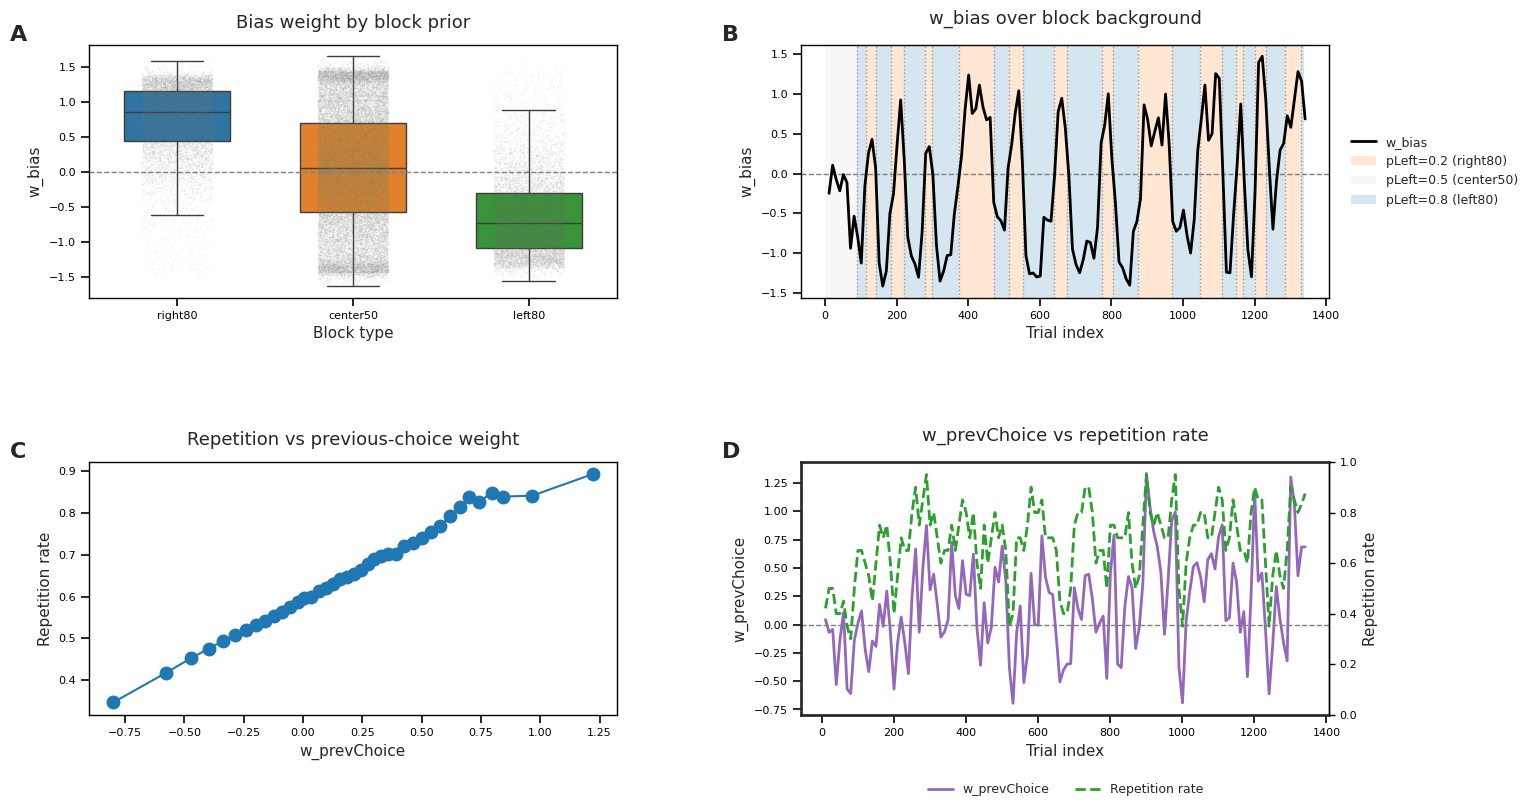

Panel B and D example: subject=ibl_witten_04, session=3d7c5f16-5d54-48a9-a74a-d71ed4f0f9ac


In [23]:
# Figure 3

# Panel A: Distribution of bias weights across block types
def plot_panel_A_box_bias(ax, pure_win, order=("right80", "center50", "left80")):
    """
    Plot bias weights across block types using a boxplot
    """
    dfp = pure_win.dropna(subset=["majority_block_type", "w_bias"]).copy()  # Keep relevant rows
    dfp["majority_block_type"] = pd.Categorical(dfp["majority_block_type"], categories=list(order), ordered=True)   # Set block types as an ordered categorical variable

    palette = {"right80": "C0", "center50": "C1", "left80": "C2"} # Define colors and order
    order = ["right80", "center50", "left80"]

    # the number of samples
    counts = dfp["majority_block_type"].value_counts().reindex(order)
    print(counts)

    # Boxplot of bias weights by block type
    sns.boxplot(
        data=dfp, x="majority_block_type", y="w_bias", hue="majority_block_type",
        order=list(order), palette=palette, width=0.6, showfliers=False, ax=ax
    )
    sns.stripplot(  # Overlay individual window-level observations
        data=dfp, x="majority_block_type", y="w_bias",
        order=list(order), color="grey", alpha=0.08, jitter=0.2, size=1.0, ax=ax
    )

    ax.axhline(0, linestyle="--", linewidth=1, color="0.5")
    ax.set_xlabel("Block type", fontsize=11)
    ax.set_ylabel("w_bias", fontsize=11)
    ax.set_title("Bias weight by block prior", pad=12, fontsize=13)

    return ax

# Shared helpers and column names
BLOCK_COL = "current_probabilityLeft"
TRIAL_COL = "trial_index"
WIN_BIAS_COL = "w_bias"
WIN_START = "win_start"
WIN_END = "win_end"
WIN_ANCHOR = "win_anchor"

def block_segments(t: np.ndarray, pleft: np.ndarray):
    """
    Convert trial-wise block prior values into block-wise segments.
    """
    pleft = np.asarray(pleft, float)
    change_idx = np.where(np.diff(pleft) != 0)[0]   # indices where block prior changes
    seg_starts = np.r_[0, change_idx + 1]   # Segment boundaries
    seg_ends = np.r_[change_idx + 1, len(t)]
    segs = []
    for s, e in zip(seg_starts, seg_ends):
        lo = int(t[s])
        hi = int(t[e - 1]) + 1  # exclusive
        segs.append((lo, hi, float(pleft[s])))
    return segs

# Panel B: Example session with w_bias and block background
def plot_panel_B_wbias_bg(
    ax,
    glm_df: pd.DataFrame,
    win_df_valid: pd.DataFrame,
    subject: str,
    session: str,
    block_alpha: float = 0.18,
    pleft_to_color: dict | None = None,
    show_transition_lines: bool = True,
    color_wbias: str = "k",
    lw_wbias: float = 2.0,
):
    """
    Plot bias-weights for one example session with block background.
    """
    g = glm_df.copy()
    g["subject"] = g["subject"].astype(str).str.strip()
    g["session"] = g["session"].astype(str).str.strip()
    g = g[(g["subject"] == str(subject)) & (g["session"] == str(session))].copy()
    if g.empty:
        raise ValueError(f"No trials for subject={subject}, session={session}")

    g[TRIAL_COL] = pd.to_numeric(g[TRIAL_COL], errors="coerce")   # Convert relevant columns to numeric
    g[BLOCK_COL] = pd.to_numeric(g[BLOCK_COL], errors="coerce")
    g = g.dropna(subset=[TRIAL_COL, BLOCK_COL]).copy()    # Remove invalid rows
    g[TRIAL_COL] = g[TRIAL_COL].astype(int)
    g = g.sort_values(TRIAL_COL)

    t = g[TRIAL_COL].to_numpy(int)    # Extract rrial indices and block priors
    pleft = g[BLOCK_COL].to_numpy(float)
    segs = block_segments(t, pleft)    # Identify contiguous segments
    if pleft_to_color is None:
        pleft_to_color = {0.2: "tab:orange", 0.5: "0.85", 0.8: "tab:blue"}

    w = win_df_valid.copy()    # Select window-level data for the same subject-session
    w["subject"] = w["subject"].astype(str).str.strip()
    w["session"] = w["session"].astype(str).str.strip()
    w = w[(w["subject"] == str(subject)) & (w["session"] == str(session))].copy()
    if w.empty:
        raise ValueError(f"No windows for subject={subject}, session={session}")

    w[WIN_BIAS_COL] = pd.to_numeric(w[WIN_BIAS_COL], errors="coerce")   # Convert relevant columns to numeric
    w[WIN_START] = pd.to_numeric(w[WIN_START], errors="coerce")
    w[WIN_END] = pd.to_numeric(w[WIN_END], errors="coerce")
    w = w.dropna(subset=[WIN_BIAS_COL, WIN_START, WIN_END]).copy()    # Remove invalid rows

    w["x"] = pd.to_numeric(w["win_anchor"], errors="coerce")    # Use window anchor as x-coordinate
    w = w.dropna(subset=["x"]).copy().sort_values("x")      # sort windows in temporal order

    xw = w["x"].to_numpy(float)   # Prepare arrays for plotting (x: window position)
    wb = w[WIN_BIAS_COL].to_numpy(float)    # (wb: bias weights)

    for (lo, hi, pv) in segs:   # Shade background based on block prior
        ax.axvspan(lo, hi, color=pleft_to_color.get(pv, "0.9"),
                   alpha=block_alpha, linewidth=0, zorder=0)

    if show_transition_lines:   # Vertical lines for block segments
        for (lo, _, _) in segs[1:]:
            ax.axvline(lo, linestyle=":", linewidth=1, color="0.6",
                       zorder=1, label="_nolegend_")

    (line_wb,) = ax.plot(   # Plot bias weight trajectores
        xw, wb, color=color_wbias, linewidth=lw_wbias,
        label="w_bias", zorder=3
    )

    ax.axhline(0, linestyle="--", linewidth=1, color="0.5",   # zero reference line
               zorder=2, label="_nolegend_")

    ax.set_xlabel("Trial index", fontsize=11)
    ax.set_ylabel("w_bias", fontsize=11)
    ax.set_title("w_bias over block background", pad=15, fontsize=13)

    proxies = [   # For block background colors
        Patch(facecolor=pleft_to_color.get(0.2, "0.9"), alpha=block_alpha, edgecolor="none",
              label="pLeft=0.2 (right80)"),
        Patch(facecolor=pleft_to_color.get(0.5, "0.9"), alpha=block_alpha, edgecolor="none",
              label="pLeft=0.5 (center50)"),
        Patch(facecolor=pleft_to_color.get(0.8, "0.9"), alpha=block_alpha, edgecolor="none",
              label="pLeft=0.8 (left80)"),
    ]

    ax.legend(
        handles=[line_wb, *proxies],
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )
    return ax

# Panel C: Repetition rate as a function of previous-choice weight
def plot_panel_C_rep_vs_prevchoice(ax, rep_df, n_bins=40):
    """
    Plot repetition rate as a function of binned previous-choice weight.
    """
    rep_df_use = rep_df.dropna(subset=["w_prevChoice", "repeat_rate"]).copy()
    d = rep_df_use.copy()
    d["bin"] = pd.qcut(d["w_prevChoice"], n_bins, duplicates="drop")

    # Compute mean previous-choice weight, mean repetition rate, and SEM of repetition rate within each bin
    g = (
        d.groupby("bin", observed=True)
         .agg(
             w_prevChoice=("w_prevChoice", "mean"),
             repeat_mean=("repeat_rate", "mean"),
             repeat_sem=("repeat_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
         )
         .reset_index(drop=True)
    )

    ax.errorbar(  # SEM error bars
        g["w_prevChoice"], g["repeat_mean"], yerr=g["repeat_sem"],
        fmt="o-", capsize=4, elinewidth=1.5, capthick=1.5, linewidth=1.5
    )
    ax.set_xlabel("w_prevChoice", fontsize=11)
    ax.set_ylabel("Repetition rate", fontsize=11)
    ax.set_title("Repetition vs previous-choice weight", pad=12, fontsize=13)
    return ax

# Panel D: Example session showing w_prevChoice and repetition rate
def plot_panel_D_prevchoice_vs_rep_from_repdf(
    ax1,
    win_df_valid: pd.DataFrame,
    rep_df: pd.DataFrame,
    subject: str,
    session: str,
    color_prev: str = "tab:purple",
    color_rep: str = "tab:green",
    lw: float = 2.0,
):
    """
    Plot window-level previous-choice weight and empirical repetition rate over trial index for one example subject-session
    """

    # Prepare window-level weights
    w = win_df_valid.copy()
    w["subject"] = w["subject"].astype(str).str.strip()
    w["session"] = w["session"].astype(str).str.strip()

    w = w[
        (w["subject"] == str(subject)) &
        (w["session"] == str(session))
    ].copy()

    if w.empty:
        raise ValueError(f"No windows for subject={subject}, session={session}")

    w["w_prevChoice"] = pd.to_numeric(w["w_prevChoice"], errors="coerce")
    w["win_start"] = pd.to_numeric(w["win_start"], errors="coerce")
    w["win_end"] = pd.to_numeric(w["win_end"], errors="coerce")
    w["win_anchor"] = pd.to_numeric(w["win_anchor"], errors="coerce")

    w = w.dropna(subset=["w_prevChoice", "win_start", "win_end", "win_anchor"]).copy()
    w["win_start"] = w["win_start"].astype(int)
    w["win_end"] = w["win_end"].astype(int)

    # Prepare repetition-rate data
    r = rep_df.copy()
    r["subject"] = r["subject"].astype(str).str.strip()
    r["session"] = r["session"].astype(str).str.strip()

    r = r[
        (r["subject"] == str(subject)) &
        (r["session"] == str(session))
    ].copy()

    if r.empty:
        raise ValueError(f"No repetition-rate rows for subject={subject}, session={session}")

    r["win_start"] = pd.to_numeric(r["win_start"], errors="coerce")
    r["win_end"] = pd.to_numeric(r["win_end"], errors="coerce")
    r["repeat_rate"] = pd.to_numeric(r["repeat_rate"], errors="coerce")

    r = r.dropna(subset=["win_start", "win_end", "repeat_rate"]).copy()
    r["win_start"] = r["win_start"].astype(int)
    r["win_end"] = r["win_end"].astype(int)

    # Merge by window identity
    d = pd.merge(
        w,
        r[["subject", "session", "win_start", "win_end", "repeat_rate"]],
        on=["subject", "session", "win_start", "win_end"],
        how="inner",
    )

    if d.empty:
        raise ValueError(
            f"No overlapping windows between win_df_valid and rep_df for "
            f"subject={subject}, session={session}"
        )

    d = d.sort_values("win_anchor").copy()

    # Plot arrays
    xw = d["win_anchor"].to_numpy(float)
    prev = d["w_prevChoice"].to_numpy(float)
    rr = d["repeat_rate"].to_numpy(float)

    # Primary axis: previous-choice weight
    (line_prev,) = ax1.plot(
        xw, prev,
        color=color_prev,
        linewidth=lw,
        label="w_prevChoice"
    )
    ax1.axhline(0, linestyle="--", color="0.5", linewidth=1, label="_nolegend_")
    ax1.set_xlabel("Trial index", fontsize=11)
    ax1.set_ylabel("w_prevChoice", fontsize=11)
    ax1.set_title("w_prevChoice vs repetition rate", pad=15, fontsize=13)

    # Secondary axis: repetition rate
    ax2 = ax1.twinx()
    (line_rep,) = ax2.plot(
        xw, rr,
        color=color_rep,
        linewidth=lw,
        linestyle="--",
        label="Repetition rate"
    )
    ax2.set_ylabel("Repetition rate", fontsize=11)
    ax2.set_ylim(0.0, 1.0)

    # Shared legend
    ax1.legend(
        handles=[line_prev, line_rep],
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        borderaxespad=0.0,
        fontsize=9
    )

    return ax1, ax2

# Build A–D figure
SUBJECT_EX = "ibl_witten_04"  # Example subject-session for Panels B and D
SESSION_EX = "3d7c5f16-5d54-48a9-a74a-d71ed4f0f9ac"

# Create figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, wspace=0.35, hspace=0.65)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

plot_panel_A_box_bias(axA, pure_win)

plot_panel_B_wbias_bg(
    axB,
    glm_df=glm_df,
    win_df_valid=win_df_valid,
    subject=SUBJECT_EX,
    session=SESSION_EX,
    block_alpha=0.18,
    color_wbias="k",
)

plot_panel_C_rep_vs_prevchoice(axC, rep_df, n_bins=40)

axD1, axD2 = plot_panel_D_prevchoice_vs_rep_from_repdf(
    axD,
    win_df_valid=win_df_valid,
    rep_df=rep_df,
    subject=SUBJECT_EX,
    session=SESSION_EX,
)

# Panel letters
axA.text(-0.15, 1.08, "A", transform=axA.transAxes, fontsize=16, fontweight="bold", va="top")
axB.text(-0.15, 1.08, "B", transform=axB.transAxes, fontsize=16, fontweight="bold", va="top")
axC.text(-0.15, 1.08, "C", transform=axC.transAxes, fontsize=16, fontweight="bold", va="top")
axD.text(-0.15, 1.08, "D", transform=axD.transAxes, fontsize=16, fontweight="bold", va="top")

# Styling
for ax in [axA, axB, axC, axD]:
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_color("black")
        sp.set_linewidth(1)
    ax.tick_params(colors="black")
    make_ticks_visible(ax, labelsize=8, length=6, width=1.2)

axD2.tick_params(colors="black", labelsize=8, length=4, width=1.0)
axD2.spines["right"].set_color("black")
axD2.spines["right"].set_linewidth(1)
plt.subplots_adjust(top=0.92, bottom=0.25)
plt.show()
# Print which subject-session was used as the example
print(f"Panel B and D example: subject={SUBJECT_EX}, session={SESSION_EX}")



---

**GMM Clustering**

Selection of The Number of Mixture Components

In [24]:
feature_cols = ["w_stim",  "w_bias", "w_prevChoice", "w_wsls"]  # Feature columns for GMM clustering

# Use only complete-case windows
win_df_gmm = win_df.dropna(subset=feature_cols).copy()
assert not win_df_gmm.empty, "No valid window to use for GMM."

X_all = win_df_gmm[feature_cols].to_numpy(dtype=float)    # Feature matrix

# Group for GroupKFold (subject-session)
groups = (
    win_df_gmm["subject"].astype(str)
    + "||"
    + win_df_gmm["session"].astype(str)
).values
n_groups = len(np.unique(groups)) # Number of subject-session groups

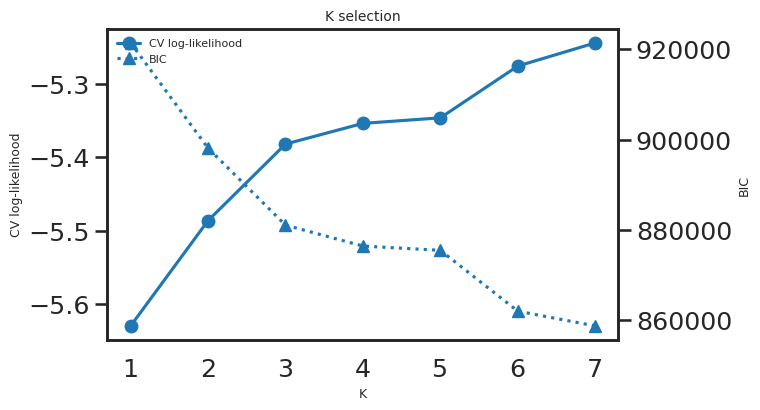

In [51]:
# K selection
K_GRID = [1, 2, 3, 4, 5, 6, 7]    # Candidate numbers of mixture components
N_SPLITS_TARGET = 5 # The number of cross-validation splits
n_splits_eff = min(N_SPLITS_TARGET, n_groups) # The number of splits cannot exceed number of groups

# BIC
# Standardize features based on full data
scaler_all = StandardScaler().fit(X_all)
Xs_all = scaler_all.transform(X_all)

bic_rows = []
for K in K_GRID:
    gmm = GaussianMixture(    # Fit GMM with K components on the full dataset
        n_components=K,       # From 1 to 7
        random_state=0,       # Seed for reproducibility of the fitting process
        n_init=10             # Multiple random initializations to to reduce sensitivity to initialization
    ).fit(Xs_all)

    bic_rows.append({"K": K, "BIC": gmm.bic(Xs_all)})   # Compute BIC for model comparison
# Store BIC results
bic_df = pd.DataFrame(bic_rows).sort_values("K").reset_index(drop=True)

# Cross-validated log-likelihood
def cv_mean_loglik_gmm(X_all, groups, n_splits_eff, K):
    """
    Compute mean test log-likelihood using GroupKFold cross-validation.
    """
    scores = []
    splitter = GroupKFold(n_splits=n_splits_eff)

    for tr_idx, te_idx in splitter.split(X_all, groups=groups):
        scaler = StandardScaler().fit(X_all[tr_idx])  # Fit scaler on training data only
        Xtr = scaler.transform(X_all[tr_idx])
        Xte = scaler.transform(X_all[te_idx])

        gmm = GaussianMixture(  # Fit GMM on training set
            n_components=K,
            random_state=0,
            n_init=10
        ).fit(Xtr)

        scores.append(gmm.score(Xte))  # Evaluate mean log-likelihood

    return float(np.mean(scores))

# Compute cross-validated log-likelihood for each K
cv_rows = []
for K in K_GRID:
    cv_ll = cv_mean_loglik_gmm(X_all, groups, n_splits_eff, K)
    cv_rows.append({"K": K, "CV_LL": cv_ll})

# Store CV results
cv_df = pd.DataFrame(cv_rows).sort_values("K").reset_index(drop=True)

# Combine BIC and CV results
merged_K = (
    bic_df[["K", "BIC"]]
    .merge(cv_df[["K", "CV_LL"]], on="K"))

# Plot for K selection (for interpretation)
fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(merged_K["K"], merged_K["CV_LL"], marker="o", label="CV log-likelihood")
ax1.set_xlabel("K", fontsize=9)
ax1.set_ylabel("CV log-likelihood", fontsize=9)
ax1.set_xticks(K_GRID)

ax2 = ax1.twinx()
ax2.plot(merged_K["K"], merged_K["BIC"], marker="^", linestyle=":", label="BIC")
ax2.set_ylabel("BIC", fontsize=9)

# legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8, frameon=False)

plt.title("K selection", fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
# Fit final GMM with selected number of states and obtain raw component assignments
N_STATES = 3  # The number of states (K)

# Standardize feature before fitting GMM
scaler = StandardScaler().fit(X_all)
X = scaler.transform(X_all)

# Fit GMM
gmm = GaussianMixture(
    n_components=N_STATES,    # Number of mixture states (K=3)
    random_state=0,           # Seed for reproducibility of the fitting process
    n_init=10                 # Multiple random initializations to to reduce sensitivity to initialization
)

# Assign each window to its most likely component (state)
# Note: component indices are arbitary (0,1,2)
win_df_gmm["component"] = gmm.fit_predict(X)
component_proba = gmm.predict_proba(X)    # Posterior probability of each state for all windows

# Store posterior probabilities for raw components
for k in range(N_STATES):
    win_df_gmm[f"component_{k}_prob"] = component_proba[:, k]

# Maximum posterior probability across components
win_df_gmm["component_prob_max"] = component_proba.max(axis=1)

           w_stim  w_bias  w_prevChoice  w_wsls
component                                      
0           1.335   0.033         0.064   0.131
1           0.487  -0.933         0.335   0.137
2           0.453   0.941         0.369   0.116


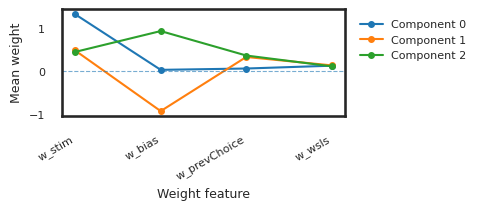

In [52]:
# Inspect raw component weight profiles

# Compute mean weight profile for each component
component_means = win_df_gmm.groupby("component")[feature_cols].mean()
print(component_means.round(3))

# Plot raw component mean profiles (for interpretation)
fig, ax = plt.subplots(figsize=(5, 2.5))

for c in sorted(component_means.index):
    ax.plot(
        feature_cols,
        component_means.loc[c].values,
        marker="o",
        linewidth=1.5,
        markersize=4,
        label=f"Component {c}"
    )

ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_ylabel("Mean weight", fontsize=9)
ax.set_xlabel("Weight feature", fontsize=9)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(1.02, 1))

ax.tick_params(axis="both", labelsize=8)

for tick in ax.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")

plt.tight_layout()
plt.subplots_adjust(right=0.75)
plt.show()

In [30]:
# Canonical relabeling of components to interpret as states

# Determine components based on their dominan weight features
stim_comp  = component_means["w_stim"].idxmax()   # Stimulus-driven: highest stimulus weight
right_comp = component_means["w_bias"].idxmax()   # Right-biased: most positive bias weight
left_comp  = component_means["w_bias"].idxmin()   # Left-biased: most negative bias weight

used = set()
component_to_state = {}

# Assign canonical state labels
# State 0: stimulus-driven
component_to_state[stim_comp] = 0
used.add(stim_comp)

# State 1: Right-biased
if right_comp in used:
    order = component_means["w_bias"].sort_values(ascending=False).index
    right_comp = next(c for c in order if c not in used)
component_to_state[right_comp] = 1
used.add(right_comp)

# State 2: Left-biased
if left_comp in used:
    order = component_means["w_bias"].sort_values(ascending=True).index
    left_comp = next(c for c in order if c not in used)
component_to_state[left_comp] = 2
used.add(left_comp)

# Assign canonical state labels
win_df_gmm["state"] = win_df_gmm["component"].map(component_to_state).astype(int)

# Reorder probabilities in canonical state order
state_to_component = {state: comp for comp, state in component_to_state.items()}

# Rearrange posterior probabilities to match state ordering
for s in range(N_STATES):
    comp = state_to_component[s]
    win_df_gmm[f"state_{s}_prob"] = component_proba[:, comp]

# Masimum posterior probability across states
win_df_gmm["state_prob_max"] = win_df_gmm[
    [f"state_{s}_prob" for s in range(N_STATES)]
].max(axis=1)

# Compute state mean profiles
state_means = win_df_gmm.groupby("state")[feature_cols].mean()
print(state_means.round(3))

       w_stim  w_bias  w_prevChoice  w_wsls
state                                      
0       1.335   0.033         0.064   0.131
1       0.453   0.941         0.369   0.116
2       0.487  -0.933         0.335   0.137


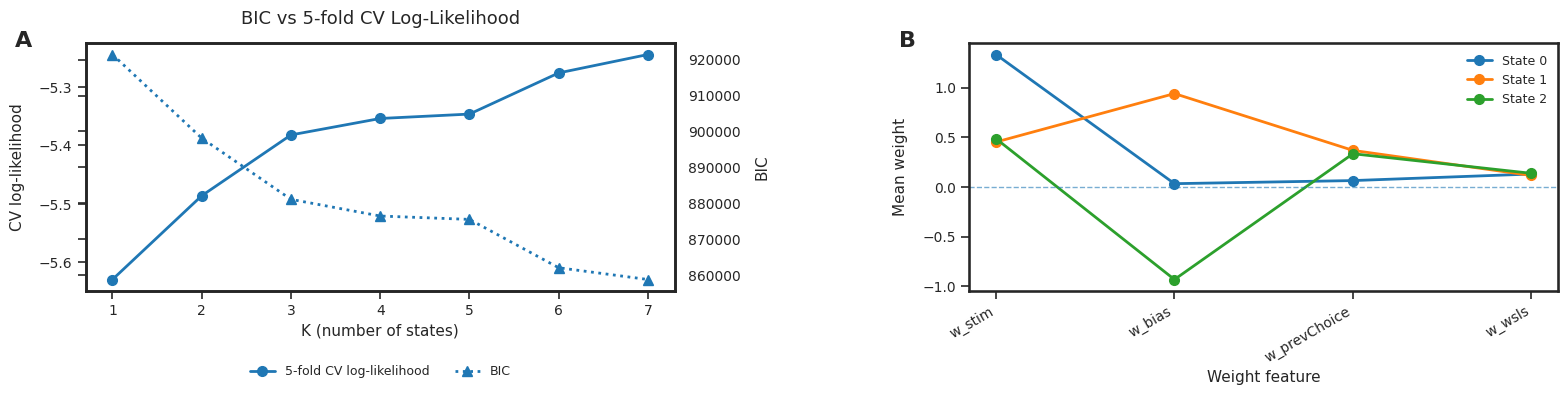

In [31]:
# Figure 4: K selection and state characterization
fig, (axA, axB) = plt.subplots(
    1, 2,
    figsize=(19, 4.5),
    gridspec_kw={"wspace": 0.5}
)

# Panel A: K selection: CV-LL and BIC
# Cross-validated log-likelihood (CV-LL)
axA.plot(
    merged_K["K"],
    merged_K["CV_LL"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="5-fold CV log-likelihood"
)
axA.set_xlabel("K (number of states)", fontsize=11)
axA.set_ylabel("CV log-likelihood", fontsize=11, labelpad=10)
axA.set_title("BIC vs 5-fold CV Log-Likelihood", fontsize=13, pad=14)

# Bayesian Information Criterion (BIC)
axA2 = axA.twinx()    # Create a second y-axis for BIC
axA2.plot(
    merged_K["K"],
    merged_K["BIC"],
    marker="^",
    linestyle=":",
    linewidth=2,
    markersize=7,
    label="BIC"
)
axA2.set_ylabel("BIC", fontsize=11, labelpad=10)

# Combined legends from both axes and place below the plot
lines1, labels1 = axA.get_legend_handles_labels()
lines2, labels2 = axA2.get_legend_handles_labels()

axA.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=False,
    borderaxespad=0.0,
    fontsize=9
)

# Panel B: State mean weight profiles
for s in sorted(state_means.index):
    axB.plot(
        feature_cols,
        state_means.loc[s].values,
        marker="o",
        linewidth=2,
        markersize=7,
        label=f"State {s}",
    )

axB.axhline(y=0, linestyle="--", linewidth=1, alpha=0.6)  # Zero horizontal reference
axB.set_ylabel("Mean weight", fontsize=11, labelpad=10)
axB.set_xlabel("Weight feature", fontsize=11)
axB.legend(loc="best", frameon=False, fontsize=9)

# Rotate x-axis labels
for tick in axB.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")
    tick.set_fontsize(10)

# Panel letters
axA.text(
    -0.12, 1.05, "A",
    transform=axA.transAxes,
    fontsize=16, fontweight="bold", va="top"
)
axB.text(
    -0.12, 1.05, "B",
    transform=axB.transAxes,
    fontsize=16, fontweight="bold", va="top"
)

# Apply tick styling
make_ticks_visible(axA, labelsize=10, length=6, width=1.2)
make_ticks_visible(axA2, labelsize=10, length=6, width=1.2)
make_ticks_visible(axB, labelsize=10, length=6, width=1.2)

# Layout
plt.subplots_adjust(
    top=0.85,
    bottom=0.30,
    wspace=0.5
)
plt.show()



---

**State Based Analyses**

Trial-Level State Assignment from Window-Level GMM Labels

In [32]:
def assign_state_to_trials(
    glm_df: pd.DataFrame,
    win_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Assign window-level state labels and posterior probabilities to trials.
    """
    # Prepare trial-level data
    trials = glm_df.copy()
    trials["subject"] = trials["subject"].astype(str).str.strip()
    trials["session"] = trials["session"].astype(str).str.strip()

    trials["trial_index"] = pd.to_numeric(trials["trial_index"], errors="coerce") # Ensure trial-index is an integer column
    trials = trials.dropna(subset=["trial_index"]).copy()
    trials["trial_index"] = trials["trial_index"].astype(int)

    # Initialize output columns
    trials["state"] = pd.Series([pd.NA] * len(trials), dtype="Int64")
    trials["state_prob_max"] = np.nan
    trials["state_0_prob"] = np.nan
    trials["state_1_prob"] = np.nan
    trials["state_2_prob"] = np.nan

    # Prepare window-level data
    win = win_df.copy()
    win["subject"] = win["subject"].astype(str).str.strip()
    win["session"] = win["session"].astype(str).str.strip()

    for c in ["win_anchor", "win_start", "win_end"]:
        win[c] = pd.to_numeric(win[c], errors="coerce")

    # Keep only windows with valid state assignments and boundaries
    win = win.dropna(subset=["state", "win_anchor", "win_start", "win_end"]).copy()

    win["win_anchor"] = win["win_anchor"].astype(int)
    win["win_start"] = win["win_start"].astype(int)
    win["win_end"] = win["win_end"].astype(int)
    win["state"] = pd.to_numeric(win["state"], errors="coerce").astype("Int64")

    # Group windows by subject-session and sort by anchor
    win_groups = {
        k: g.sort_values("win_anchor")
        for k, g in win.groupby(["subject", "session"], sort=False)
    }

    # Assign state to trials session by session
    for (subj, ses), tr_sub in trials.groupby(["subject", "session"], sort=False):
        key = (subj, ses)
        if key not in win_groups:
            continue

        w_sub = win_groups[key]

        # Extract windo-level arrays
        anchors = w_sub["win_anchor"].to_numpy()
        wstart = w_sub["win_start"].to_numpy()
        wend = w_sub["win_end"].to_numpy()
        wstate = w_sub["state"].to_numpy()
        wspm = w_sub["state_prob_max"].to_numpy()
        wp0 = w_sub["state_0_prob"].to_numpy()
        wp1 = w_sub["state_1_prob"].to_numpy()
        wp2 = w_sub["state_2_prob"].to_numpy()

        t = tr_sub["trial_index"].to_numpy(dtype=int)   # Trial indices
        tr_idx = tr_sub.index.to_numpy()

        # Identify nearest window anchors
        pos = np.searchsorted(anchors, t, side="left")
        prev_i = pos - 1  # previous anchor
        next_i = pos      # next anchor

        prev_valid = prev_i >= 0
        next_valid = next_i < len(anchors)

        prev_dist = np.full(len(t), np.inf, dtype=float)  # Initialize distances
        next_dist = np.full(len(t), np.inf, dtype=float)

        # Distance to previous anchor
        if prev_valid.any():
            pi = prev_i[prev_valid]
            tt = t[prev_valid]
            cover = (wstart[pi] <= tt) & (tt < wend[pi])
            prev_dist[prev_valid] = np.where(cover, np.abs(anchors[pi] - tt), np.inf)

        # Distance to next anchor
        if next_valid.any():
            ni = next_i[next_valid]
            tt = t[next_valid]
            cover = (wstart[ni] <= tt) & (tt < wend[ni])
            next_dist[next_valid] = np.where(cover, np.abs(anchors[ni] - tt), np.inf)

        # Choose the closest window
        choose_prev = prev_dist <= next_dist
        best_dist = np.minimum(prev_dist, next_dist)
        any_valid = np.isfinite(best_dist)

        best_i = np.full(len(t), -1, dtype=int)
        best_i[choose_prev & any_valid] = prev_i[choose_prev & any_valid]
        best_i[(~choose_prev) & any_valid] = next_i[(~choose_prev) & any_valid]

        # Assign window-level values to trials
        valid_rows = best_i >= 0
        if valid_rows.any():
            bi = best_i[valid_rows]
            idx = tr_idx[valid_rows]

            trials.loc[idx, "state"] = pd.Series(wstate[bi]).astype("Int64").to_numpy()
            trials.loc[idx, "state_prob_max"] = wspm[bi]
            trials.loc[idx, "state_0_prob"] = wp0[bi]
            trials.loc[idx, "state_1_prob"] = wp1[bi]
            trials.loc[idx, "state_2_prob"] = wp2[bi]

    return trials

# Apply function
glm_with_state = assign_state_to_trials(glm_df, win_df_gmm)

In [33]:
# Canonical label / order / palette for each state
# Label
state_names = {
    0: "Stimulus-driven",
    1: "Right-biased",
    2: "Left-biased",}

# Order
order_states = ["Stimulus-driven", "Right-biased", "Left-biased"]

# Palette
name_palette = {
    "Stimulus-driven": "C0",
    "Right-biased": "C1",
    "Left-biased": "C2",
}
# Color mapping for numeric state IDs
state_palette = {k: name_palette[v] for k, v in state_names.items()}

def add_state_labels(df, state_col="state"):
    """
    Convert state labels to canonical labels.
    """
    df = df.copy()
    df[state_col] = pd.to_numeric(df[state_col], errors="coerce")   # Convert the state column to numeric
    df = df.dropna(subset=[state_col]).copy()   # Drop rows where state is missing
    df[state_col] = df[state_col].astype(int)   # Convert state to integer

    df["state_name"] = df[state_col].map(state_names) # Map numeric state labels to canonical state names
    df = df.dropna(subset=["state_name"]).copy()  # Drop rows where mapping failed
    df["state_name"] = pd.Categorical(df["state_name"], categories=order_states, ordered=True) # Convert state_name to an ordered categorical variable for plotting
    return df

# Apply function
glm_with_state = add_state_labels(glm_with_state, state_col="state")



---

Accuracy by State

In [34]:
# Accuracy
df = glm_with_state.copy()

# preprocessing
df["current_correct"] = pd.to_numeric(df["current_correct"], errors="coerce")
df["current_signed_contrast"] = pd.to_numeric(df["current_signed_contrast"], errors="coerce")
df = df.dropna(subset=["current_correct"]).copy()
df["current_correct"] = df["current_correct"].astype(int)

# Compute mean accuracy and number of trials by state
overall = (
    df.groupby("state_name", observed=False)["current_correct"]
      .agg(p_correct="mean", n_trials="size")
      .reindex(order_states)
      .reset_index()
)
# Compute overall accuracy (baseline)
overall_acc = df["current_correct"].mean()

# Accuracy as a function of signed contrast
df2 = df.dropna(subset=["current_signed_contrast"]).copy()

# Compute accuracy per state and contrast
contrast_acc = (
    df2.groupby(["state_name", "current_signed_contrast"], observed=False)["current_correct"]
        .agg(p_correct="mean", n_trials="size")
        .reset_index()
        .rename(columns={"current_signed_contrast": "contrast_x"})
)

In [35]:
# Empirical Psychometric Characterization by State
df_choice = glm_with_state.copy()

# Required columns check
need = ["state", "current_choice", "current_signed_contrast", "state_name"]
missing = [c for c in need if c not in df_choice.columns]
if missing:
    raise KeyError(f"glm_with_state missing columns: {missing}")

# Ensure numeric types
df_choice["state"] = pd.to_numeric(df_choice["state"], errors="coerce")
df_choice["current_choice"] = pd.to_numeric(df_choice["current_choice"], errors="coerce")
df_choice["current_signed_contrast"] = pd.to_numeric(df_choice["current_signed_contrast"], errors="coerce")

# Drop invalid rows
df_choice = df_choice.dropna(subset=["state", "current_choice", "current_signed_contrast"]).copy()
df_choice["state"] = df_choice["state"].astype(int)

# Define rightward choice (IBL: left=+1, right=-1)
df_choice["is_right"] = (df_choice["current_choice"] < 0).astype(int)

# Overall P(right) per state
overall_right = (
    df_choice.groupby("state_name", observed=False)["is_right"]
             .agg(p_right="mean", n_trials="size")
             .reindex(order_states)
             .reset_index()
)

# P(right) as a function of signed contrast
right_by_contrast = (
    df_choice.groupby(["state_name", "current_signed_contrast"], observed=False)["is_right"]
             .agg(p_right="mean", n_trials="size")
             .reset_index()
             .rename(columns={"current_signed_contrast": "contrast_x"})
)

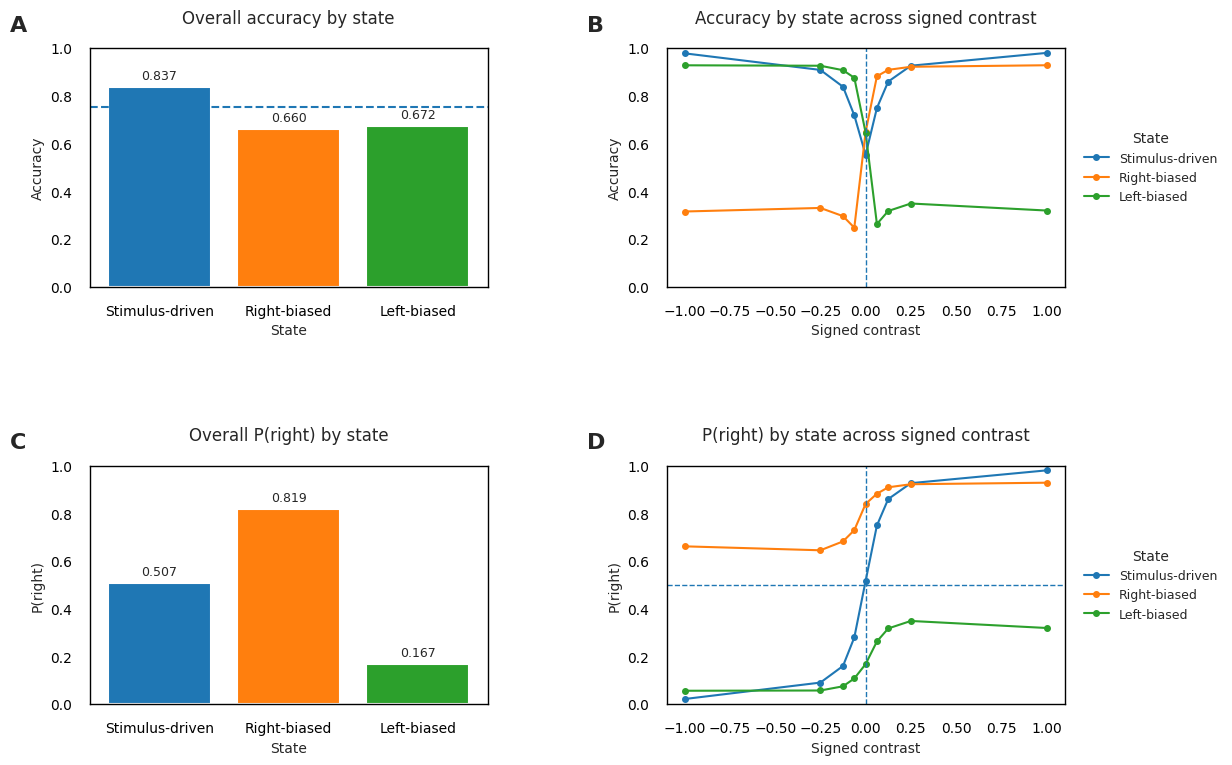

In [36]:
# Figure 5
fig = plt.figure(figsize=(12.5, 8.2))
gs = fig.add_gridspec(2, 2, wspace=0.45, hspace=0.75)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

# Panel A: Overall accuracy by state
bar_colors = [name_palette[s] for s in overall["state_name"]]
bars = axA.bar(overall["state_name"], overall["p_correct"], color=bar_colors)

axA.set_ylim(0, 1)
axA.set_xlabel("State", fontsize=10)
axA.set_ylabel("Accuracy", fontsize=10)
axA.set_title("Overall accuracy by state", pad=18, fontsize=12)

for rect, p in zip(bars, overall["p_correct"].to_numpy()):
    axA.text(rect.get_x() + rect.get_width()/2,
             rect.get_height() + 0.02,
             f"{p:.3f}",
             ha="center", va="bottom", fontsize=9)

axA.axhline(overall_acc, linestyle="--", linewidth=1.5)

# Panel B: Accuracy by state across signed contrast
for name in order_states:
    sub = contrast_acc[contrast_acc["state_name"] == name].sort_values("contrast_x")
    axB.plot(sub["contrast_x"], sub["p_correct"],
             marker="o", label=name, color=name_palette[name],
             linewidth=1.5, markersize=4)

axB.axvline(0, linestyle="--", linewidth=1)
axB.set_xlabel("Signed contrast", fontsize=10)
axB.set_ylabel("Accuracy", fontsize=10)
axB.set_ylim(0, 1)
axB.set_title("Accuracy by state across signed contrast", pad=18, fontsize=12)

# Legend outside
axB.legend(
    title="State",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10
)

# Panel C: Overall P(right) by state
bar_colors = [name_palette[s] for s in overall_right["state_name"]]
bars = axC.bar(overall_right["state_name"], overall_right["p_right"], color=bar_colors)

axC.set_ylim(0, 1)
axC.set_xlabel("State", fontsize=10)
axC.set_ylabel("P(right)", fontsize=10)
axC.set_title("Overall P(right) by state", pad=18, fontsize=12)

for rect, p in zip(bars, overall_right["p_right"].to_numpy()):
    axC.text(rect.get_x() + rect.get_width()/2,
             rect.get_height() + 0.02,
             f"{p:.3f}",
             ha="center", va="bottom", fontsize=9)

# Panel D: P(right) by state across signed contrast
for name in order_states:
    sub = right_by_contrast[right_by_contrast["state_name"] == name].sort_values("contrast_x")
    axD.plot(sub["contrast_x"], sub["p_right"],
             marker="o", label=name, color=name_palette[name],
             linewidth=1.5, markersize=4)

axD.axhline(0.5, linewidth=1, linestyle="--")
axD.axvline(0.0, linewidth=1, linestyle="--")
axD.set_xlabel("Signed contrast", fontsize=10)
axD.set_ylabel("P(right)", fontsize=10)
axD.set_ylim(0, 1)
axD.set_title("P(right) by state across signed contrast", pad=18, fontsize=12)

axD.legend(
    title="State",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10
)

# Panel letters
axA.text(-0.20, 1.14, "A", transform=axA.transAxes, fontsize=16, fontweight="bold", va="top")
axB.text(-0.20, 1.14, "B", transform=axB.transAxes, fontsize=16, fontweight="bold", va="top")
axC.text(-0.20, 1.14, "C", transform=axC.transAxes, fontsize=16, fontweight="bold", va="top")
axD.text(-0.20, 1.14, "D", transform=axD.transAxes, fontsize=16, fontweight="bold", va="top")

# Styling: remove grid + make spines black
for ax in [axA, axB, axC, axD]:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)
    ax.tick_params(axis="both", colors="black", labelsize=10)

plt.subplots_adjust(
    top=0.90,
    bottom=0.10,
    left=0.08,
    right=0.86,
    wspace=0.45,
    hspace=0.75)

plt.show()



---

State Occupancy

In [37]:
# State occupancy (Fractional occupancy)
df_occ = glm_with_state.copy()

# Ensure state column is numeric and remove invalid entries
df_occ["state"] = pd.to_numeric(df_occ["state"], errors="coerce")
df_occ = df_occ.dropna(subset=["state"]).copy()
df_occ["state"] = df_occ["state"].astype(int)

# Count number of trials per state
occ = (
    df_occ.groupby("state_name", observed=False)
          .size()                   # number of trials assigned to each state
          .rename("n_trials")
          .reindex(order_states)    # enforce consistent state ordering
          .reset_index()
)

# Compute fractional occupancy
occ["fraction"] = occ["n_trials"] / occ["n_trials"].sum()

In [38]:
# FO per contrast level
df_contrast = glm_with_state.copy()

# Ensure valid rows
df_contrast = df_contrast.dropna(subset=["state", "current_signed_contrast"]).copy()
df_contrast["state"] = df_contrast["state"].astype(int)

# Count trials per contrast level and state
ct = (
    df_contrast.groupby(["current_signed_contrast", "state_name"], observed=False)
               .size()
               .rename("n")
               .reset_index()
)

# Compute fractional occupancy within each contrast level
ct["fraction"] = ct.groupby("current_signed_contrast")["n"].transform(lambda x: x / x.sum())

# Pivot to wide format (contrast × state)
pivot = (
    ct.pivot(index="current_signed_contrast", columns="state_name", values="fraction")
      .reindex(columns=order_states)
      .fillna(0.0)
)

In [39]:
# FO per block prior
df_block = glm_with_state.copy()

df_block = df_block.dropna(subset=["state", "current_probabilityLeft"]).copy()
df_block["state"] = df_block["state"].astype(int)

# snap
levels = np.array([0.2, 0.5, 0.8])
x = df_block["current_probabilityLeft"].to_numpy()
df_block["p_left_level"] = levels[np.argmin(np.abs(x[:, None] - levels[None, :]), axis=1)]

# pooled counts
ct_block = (
    df_block.groupby(["p_left_level", "state_name"], observed=False)
            .size()
            .rename("n")
            .reset_index()
)

# normalize within each block
ct_block["fraction"] = (
    ct_block.groupby("p_left_level")["n"]
            .transform(lambda x: x / x.sum())
)

In [40]:
# Dwell time
def compute_runs_all_sessions(df_in, state_col="state", trial_col="trial_index"):
    """
    Convert trial-level state assignments into run-level dwell events across all sessions.
    A 'run' is defined as a contiguous sequence of trials assigned to the same state
    within a given subject-session.
    """
    d = df_in.copy()
    d["subject"] = d["subject"].astype(str).str.strip()
    d["session"] = d["session"].astype(str).str.strip()

    # Numeric cleaning
    d[state_col] = pd.to_numeric(d[state_col], errors="coerce")
    d[trial_col] = pd.to_numeric(d[trial_col], errors="coerce")
    d = d.dropna(subset=["subject", "session", state_col, trial_col]).copy()
    d[state_col] = d[state_col].astype(int)
    d[trial_col] = d[trial_col].astype(int)

    out = []

    # Process each subject-session separately to identify contiguous runs
    for (subj, ses), g in d.groupby(["subject", "session"], sort=False):
        g = g.sort_values(trial_col).reset_index(drop=True)
        st = g[state_col].to_numpy()

        # Run boundary = state change
        change = np.r_[True, st[1:] != st[:-1]]
        run_id = change.cumsum() - 1

        g = g.copy()
        g["run_id"] = run_id

        runs = (
            g.groupby("run_id")
             .agg(
                 state=(state_col, "first"),
                 start_trial=(trial_col, "min"),
                 end_trial=(trial_col, "max"),
                 dwell_trials=(trial_col, "size"),
             )
             .reset_index()
        )

        runs["subject"] = subj
        runs["session"] = ses
        runs["state_name"] = runs["state"].map(state_names)
        runs["state_name"] = pd.Categorical(
            runs["state_name"],
            categories=order_states,
            ordered=True
        )

        out.append(runs)

    if not out:
        return pd.DataFrame(
            columns=[
                "subject", "session", "run_id", "state", "state_name",
                "start_trial", "end_trial", "dwell_trials"
            ]
        )

    return pd.concat(out, ignore_index=True)


# Apply function: convert trial-level state sequences into run-level dwell events
runs_all = compute_runs_all_sessions(
    glm_with_state,
    state_col="state",
    trial_col="trial_index"
)

# Pooled summary across all runs
summary_dwell_pooled = (
    runs_all.groupby("state_name", observed=False)["dwell_trials"]
            .agg(
                mean="mean",
                sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
            )
            .reindex(order_states)
            .reset_index()
)

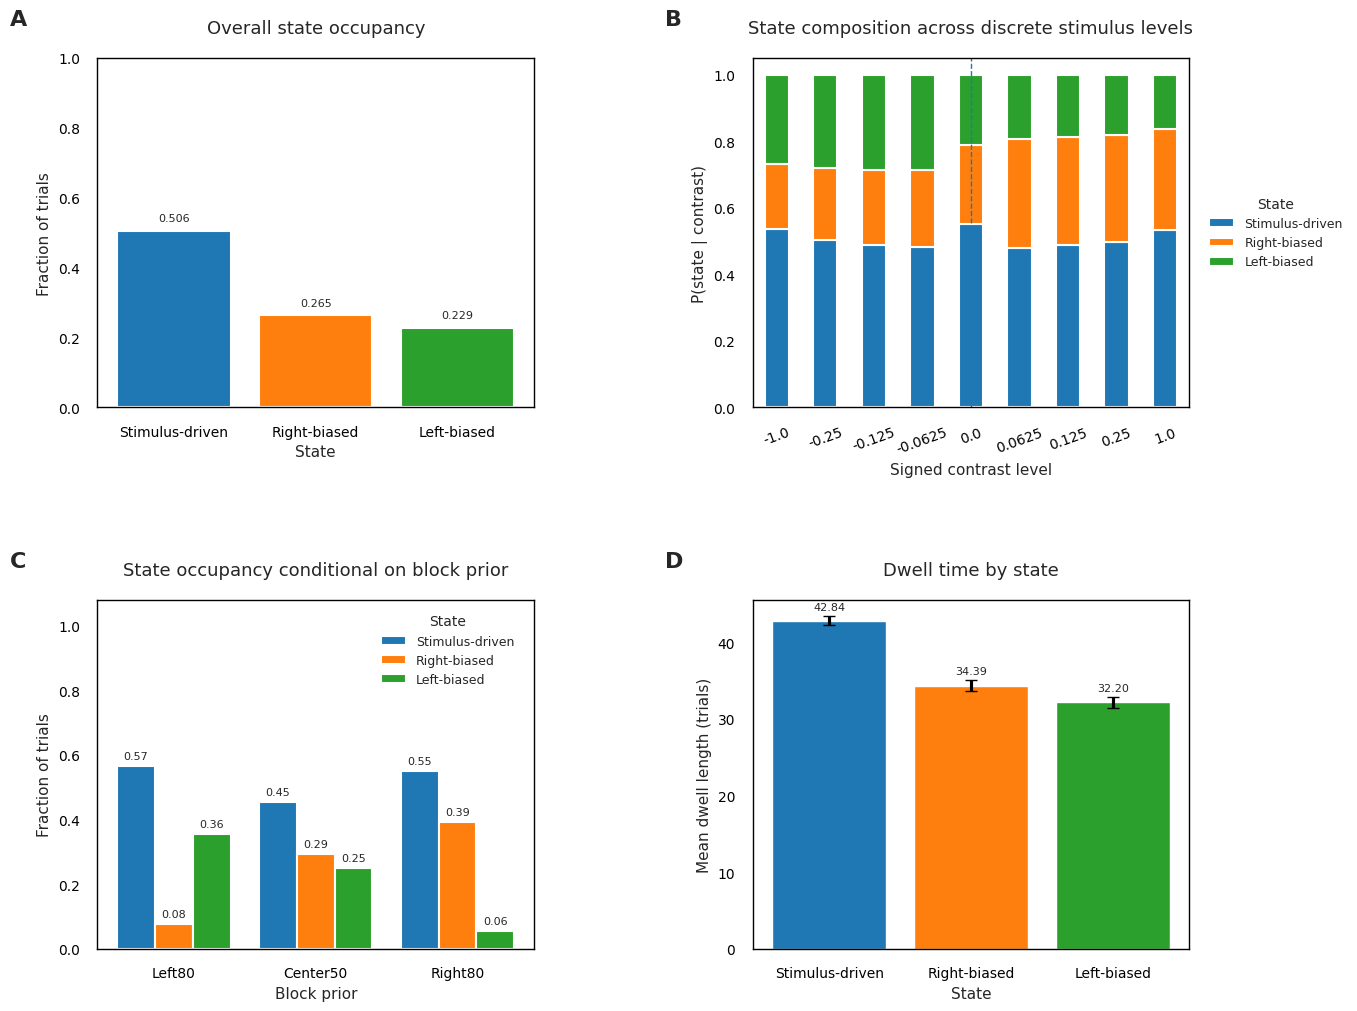

In [41]:
# Figure 6

# Explicit plotting order
state_order = list(order_states)
block_order = [0.8, 0.5, 0.2]

# If needed, enforce categorical ordering for consistent plotting
occ["state_name"] = pd.Categorical(occ["state_name"], categories=state_order, ordered=True)
ct_block["state_name"] = pd.Categorical(ct_block["state_name"], categories=state_order, ordered=True)
summary_dwell_pooled["state_name"] = pd.Categorical(summary_dwell_pooled["state_name"], categories=state_order, ordered=True)

# Reorder tables used for plotting
occ_plot = occ.sort_values("state_name").reset_index(drop=True)
ct_block_plot  = ct_block.sort_values(["p_left_level", "state_name"]).reset_index(drop=True)
summary_dwell_plot  = summary_dwell_pooled.sort_values("state_name").reset_index(drop=True)

# For panel B, make sure rows/columns are in the intended order
pivot_plot = (
    pivot.reindex(columns=state_order)
         .sort_index()
)

# For panel C, convert long -> wide for grouped bars
block_wide = (
    ct_block_plot
    .pivot(index="p_left_level", columns="state_name", values="fraction")
    .reindex(index=block_order, columns=state_order)
    .fillna(0.0)
)

# Layout
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(2, 2, wspace=0.50, hspace=0.55)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])


# Panel A: Overall occupancy
bar_colors = [name_palette[s] for s in occ_plot["state_name"]]
bars = axA.bar(occ_plot["state_name"], occ_plot["fraction"], color=bar_colors)

axA.set_ylim(0, 1)
axA.set_xlabel("State", fontsize=11)
axA.set_ylabel("Fraction of trials", fontsize=11)
axA.set_title("Overall state occupancy", pad=18, fontsize=13)

for rect, frac in zip(bars, occ_plot["fraction"].to_numpy()):
    axA.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 0.02,
        f"{frac:.3f}",
        ha="center", va="bottom", fontsize=8
    )

# Panel B: Composition by contrast (stacked)
pivot_plot.plot(
    kind="bar",
    stacked=True,
    ax=axB,
    color=[name_palette[s] for s in pivot_plot.columns]
)

if 0.0 in pivot_plot.index:
    axB.axvline(x=list(pivot_plot.index).index(0.0), linestyle="--", linewidth=1)

axB.set_xlabel("Signed contrast level", fontsize=11)
axB.set_ylabel("P(state | contrast)", fontsize=11)
axB.set_title("State composition across discrete stimulus levels", pad=18, fontsize=13)

axB.set_xticks(range(len(pivot_plot.index)))
axB.set_xticklabels([str(x) for x in pivot_plot.index], rotation=20, fontsize=8)

axB.legend(
    title="State",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    title_fontsize=10
)

# Panel C: Occupancy by block prior
x = np.arange(len(block_order))
n_states = len(state_order)
width = 0.8 / n_states

for i, state in enumerate(state_order):
    heights = block_wide[state].to_numpy()
    xpos = x + (i - (n_states - 1) / 2) * width

    bars = axC.bar(
        xpos,
        heights,
        width=width,
        color=name_palette[state],
        label=state
    )

    for rect, frac in zip(bars, heights):
        axC.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.015,
            f"{frac:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


axC.set_xlabel("Block prior", fontsize=11)
axC.set_ylabel("Fraction of trials", fontsize=11)
axC.set_title("State occupancy conditional on block prior", pad=18, fontsize=13)

block_label_map = {0.8: "Left80", 0.5: "Center50", 0.2: "Right80"}
axC.set_xticks(x)
axC.set_xticklabels([block_label_map.get(v, str(v)) for v in block_order], rotation=0)
axC.set_ylim(0, 1.08)

axC.legend(
    title="State",
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.99),
    fontsize=9,
    title_fontsize=10
)

# Panel D: Dwell time by state (mean ± SEM)
bars_d = axD.bar(
    summary_dwell_plot["state_name"],
    summary_dwell_plot["mean"],
    yerr=summary_dwell_plot["sem"],
    capsize=4,
    linewidth=1,
    color=[name_palette[s] for s in summary_dwell_plot["state_name"]]
)

axD.set_xlabel("State", fontsize=11)
axD.set_ylabel("Mean dwell length (trials)", fontsize=11)
axD.set_title("Dwell time by state", pad=18, fontsize=13)

for rect, mu, sem in zip(
    bars_d,
    summary_dwell_plot["mean"].to_numpy(),
    summary_dwell_plot["sem"].to_numpy()):
    axD.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + sem + 0.5,
        f"{mu:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

axD.set_xlabel("State", fontsize=11)
axD.set_ylabel("Mean dwell length (trials)", fontsize=11)
axD.set_title("Dwell time by state", pad=18, fontsize=13)

# Panel letters
axA.text(-0.20, 1.14, "A", transform=axA.transAxes, fontsize=16, fontweight="bold", va="top")
axB.text(-0.20, 1.14, "B", transform=axB.transAxes, fontsize=16, fontweight="bold", va="top")
axC.text(-0.20, 1.14, "C", transform=axC.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")
axD.text(-0.20, 1.14, "D", transform=axD.transAxes, fontsize=16, fontweight="bold", va="top")

# Styling: remove grid + black spines
for ax in [axA, axB, axC, axD]:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)
    ax.tick_params(colors="black", labelsize=10)

plt.subplots_adjust(
    top=0.90,
    bottom=0.09,
    left=0.08,
    right=0.86,
    wspace=0.50,
    hspace=0.55
)
plt.show()

In [42]:
summary_dwell_pooled = (
    runs_all.groupby("state_name", observed=False)["dwell_trials"]
            .agg(
                mean="mean",
                median="median",
                sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
            )
            .reindex(order_states)
            .reset_index()
)
print(summary_dwell_pooled)

        state_name       mean  median       sem
0  Stimulus-driven  42.839956    30.0  0.579270
1     Right-biased  34.389133    20.0  0.726439
2      Left-biased  32.202772    20.0  0.711829


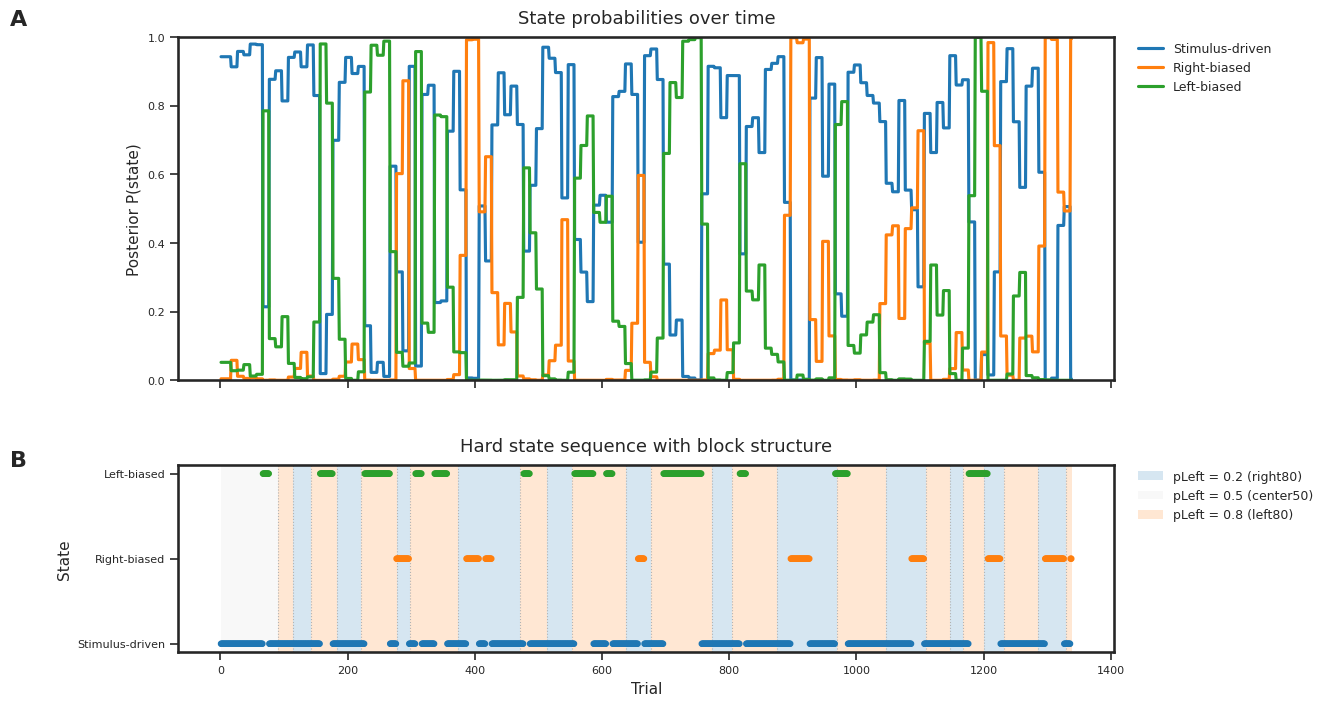

Example session: subject=ibl_witten_04, session=3d7c5f16-5d54-48a9-a74a-d71ed4f0f9ac


In [43]:
# Figure 7
def plot_state_dynamics_one_session_labeled(
    df_in,
    subject,
    session,
    trial_col="trial_index",
    prob_cols=("state_0_prob", "state_1_prob", "state_2_prob"),
    state_col="state",
    block_col="current_probabilityLeft",
    state_names=None,
    state_palette=None,
    block_colors=None,
    block_alpha=0.18,
):
    """
    Plot state dynamics for one subject-session.
    Panels:
      A. Posterior state probabilities across trials
      B. Hard state assignments across trials with block background
    """
    if state_names is None:
        state_names = {0: "Stimulus-driven", 1: "Right-biased", 2: "Left-biased"}

    if block_colors is None:
        block_colors = {
            0.2: "tab:blue",     # right80
            0.5: "0.85",         # center50
            0.8: "tab:orange",   # left80
        }

    if state_palette is None:
        state_palette = {k: name_palette[v] for k, v in state_names.items()}

    # Filter one session
    d = df_in.copy()
    d["subject"] = d["subject"].astype(str).str.strip()
    d["session"] = d["session"].astype(str).str.strip()

    d = d[(d["subject"] == str(subject)) & (d["session"] == str(session))].copy()
    if d.empty:
        raise ValueError(f"No data for subject={subject}, session={session}")

    # Clean and sort trial index
    d[trial_col] = pd.to_numeric(d[trial_col], errors="coerce")
    d = d.dropna(subset=[trial_col]).copy()
    d[trial_col] = d[trial_col].astype(int)
    d = d.sort_values(trial_col).reset_index(drop=True)

    x = d[trial_col].to_numpy()

    # Clean state column
    st = pd.to_numeric(d[state_col], errors="coerce")
    has_state = st.notna().any()

    # Check posterior columns
    missing_prob_cols = [c for c in prob_cols if c not in d.columns]
    if missing_prob_cols:
        raise ValueError(f"Posterior columns not found: {missing_prob_cols}")

    # Block availability
    has_block = block_col in d.columns
    if has_block:
        d[block_col] = pd.to_numeric(d[block_col], errors="coerce")

    fig, axes = plt.subplots(
        2, 1,
        figsize=(13, 7.5),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.2]}
    )

    # Panel A: posterior probabilities
    ax = axes[0]
    ax.text(-0.18, 1.08, "A", transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top", ha="left")

    for s, c in enumerate(prob_cols):
        y = pd.to_numeric(d[c], errors="coerce").to_numpy()
        ax.plot(
            x, y,
            label=state_names.get(s, f"State {s}"),
            color=state_palette.get(s, None)
        )

    ax.set_ylabel("Posterior P(state)", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title("State probabilities over time", pad=10, fontsize=13)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        borderaxespad=0.0,
        fontsize=9
    )

    # Panel B: hard state sequence
    ax2 = axes[1]
    ax2.text(-0.18, 1.08, "B", transform=ax2.transAxes,
             fontsize=16, fontweight="bold", va="top", ha="left")

    segs = block_segments(x, d[block_col].to_numpy()) if has_block else []

    if has_block:
        for lo, hi, bval in segs:
            ax2.axvspan(
                lo, hi,
                color=block_colors.get(bval, "0.9"),
                alpha=block_alpha,
                linewidth=0,
                zorder=0
            )

    if has_state:
        mask = st.notna().to_numpy()
        st_int = st[mask].astype(int).to_numpy()

        ax2.scatter(
            x[mask],
            st_int,
            s=10,
            c=[state_palette.get(int(v), "k") for v in st_int],
            zorder=2
        )

        yticks = sorted(np.unique(st_int))
        ax2.set_yticks(yticks)
        ax2.set_yticklabels([state_names.get(int(s), str(s)) for s in yticks], fontsize=9)
    else:
        ax2.text(0.02, 0.6, "No valid hard state values.", transform=ax2.transAxes)

    if has_block:
        for _, hi, _ in segs[:-1]:
            ax2.axvline(hi, color="0.7", linestyle=":", linewidth=0.8, zorder=1)

        block_handles = [
            Patch(facecolor=block_colors.get(0.2, "0.9"), alpha=block_alpha, edgecolor="none",
                  label="pLeft = 0.2 (right80)"),
            Patch(facecolor=block_colors.get(0.5, "0.9"), alpha=block_alpha, edgecolor="none",
                  label="pLeft = 0.5 (center50)"),
            Patch(facecolor=block_colors.get(0.8, "0.9"), alpha=block_alpha, edgecolor="none",
                  label="pLeft = 0.8 (left80)"),
        ]
        ax2.legend(
            handles=block_handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            frameon=False,
            borderaxespad=0.0,
            fontsize=9
        )

    ax2.set_ylabel("State", fontsize=11)
    ax2.set_xlabel("Trial", fontsize=11)
    ax2.set_title("Hard state sequence with block structure", pad=10, fontsize=13)

    plt.subplots_adjust(
        left=0.10,
        right=0.82,
        top=0.92,
        bottom=0.10,
        hspace=0.32
    )
    for a in [ax, ax2]:
        a.tick_params(axis="both", labelsize=8)
        make_ticks_visible(a, labelsize=8, length=6, width=1.2)
    plt.show()

SUBJECT_EX = "ibl_witten_04"
SESSION_EX = "3d7c5f16-5d54-48a9-a74a-d71ed4f0f9ac"

plot_state_dynamics_one_session_labeled(
    glm_with_state,
    subject=SUBJECT_EX,
    session=SESSION_EX,
    state_names=state_names,
    state_palette=state_palette,)

print(f"Example session: subject={SUBJECT_EX}, session={SESSION_EX}")



---

Within-state Weight Trajectories

In [44]:
# Weight Trajectories within states
BIN_SIZE = 20
FEATURE_COLS = ["w_stim", "w_bias", "w_prevChoice", "w_wsls"]

# Mean + SEM helper
def mean_sem(x: np.ndarray):
    """
    Return mean and SEM for a numeric array, ignoring non-finite values.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n == 0:
        return np.nan, np.nan

    mu = x.mean()
    sem = x.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
    return mu, sem

def sem_safe(x: np.ndarray):
    """
    Return SEM for a numeric array, ignoring non-finite values.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    return x.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan

In [45]:
# Preprocessing for weight-trajectories within states
need_cols = ["subject", "session", "win_anchor", "state"] + FEATURE_COLS

df_time = win_df_gmm.dropna(subset=need_cols).copy()
df_time["subject"] = df_time["subject"].astype(str).str.strip()
df_time["session"] = df_time["session"].astype(str).str.strip()
df_time["win_anchor"] = pd.to_numeric(df_time["win_anchor"], errors="coerce")
df_time["state"] = pd.to_numeric(df_time["state"], errors="coerce")

df_time = df_time.dropna(subset=["win_anchor", "state"]).copy()
df_time["win_anchor"] = df_time["win_anchor"].astype(int)
df_time["state"] = df_time["state"].astype(int)

# Make time bins based on the window anchor
df_time["time_bin"] = (df_time["win_anchor"] // BIN_SIZE).astype(int)

# Compute the middle point of bins for x-axis
time_bins_sorted = np.sort(df_time["time_bin"].unique())
bin_centers = (time_bins_sorted + 0.5) * BIN_SIZE

# Compute the number of sessions contributing over time
n_sess_overall = (
    df_time.groupby("time_bin")[["subject", "session"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
    .rename("n_sessions")
    .reset_index()
)
n_sess_overall["bin_center"] = (n_sess_overall["time_bin"] + 0.5) * BIN_SIZE

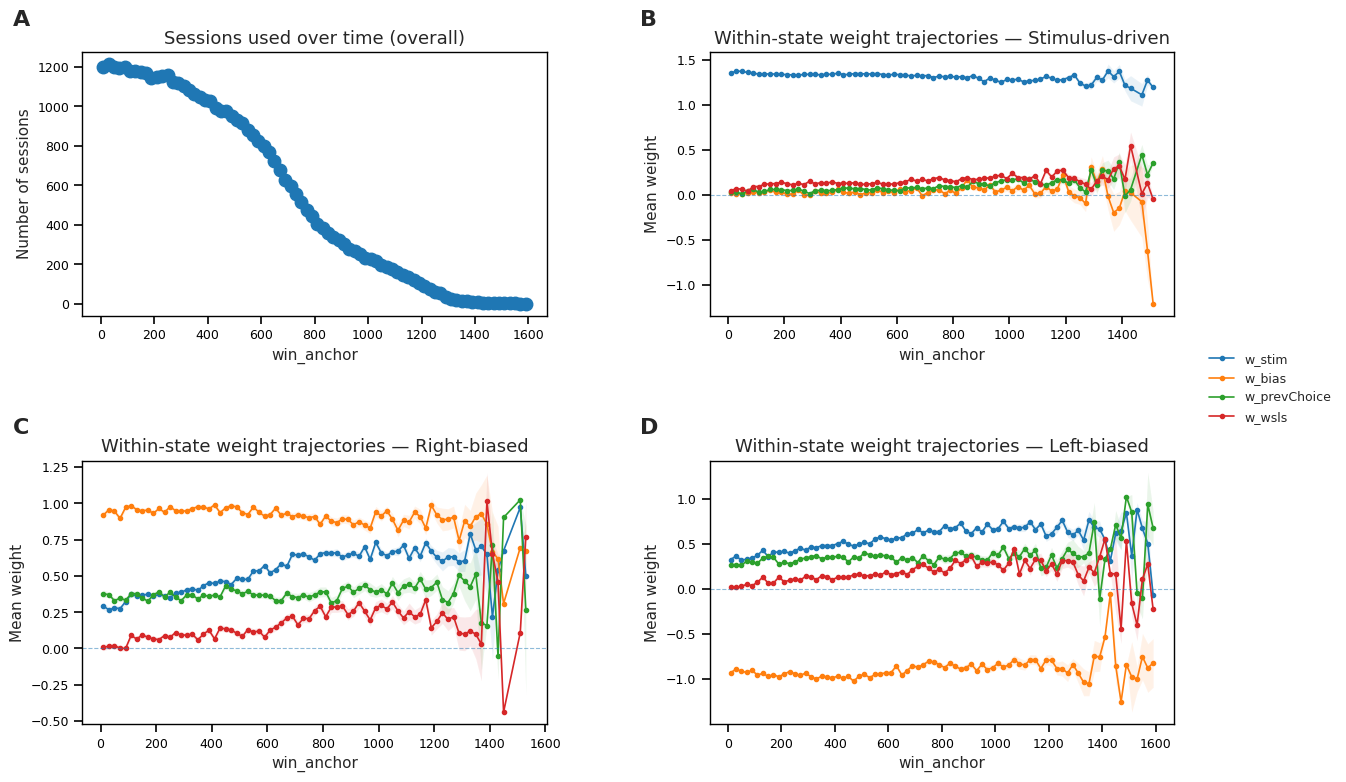

In [46]:
def plot_state_panel(ax, df, state_id, time_bins_sorted, bin_centers, feature_cols, state_names):
    """
    Plot mean and SEM weight trajectories across time bins for each state.
    """
    for weight_col in feature_cols:
        means = np.full(len(time_bins_sorted), np.nan)
        sems = np.full(len(time_bins_sorted), np.nan)

        for i, tb in enumerate(time_bins_sorted):
            g = df[(df["time_bin"] == tb) & (df["state"] == state_id)]
            mu, se = mean_sem(g[weight_col].to_numpy(dtype=float))
            means[i] = mu
            sems[i] = se

        mask = np.isfinite(means)

        # Plot mean and SEM
        ax.plot(
            bin_centers[mask],
            means[mask],
            marker="o",
            markersize=3,
            linewidth=1.2,
            label=weight_col,
        )
        ax.fill_between(
            bin_centers[mask],
            means[mask] - sems[mask],
            means[mask] + sems[mask],
            alpha=0.10,
        )

    ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("win_anchor", fontsize=11)
    ax.set_ylabel("Mean weight", fontsize=11)
    ax.set_title(f"Within-state weight trajectories — {state_names.get(state_id, state_id)}", fontsize=13)
    ax.grid(False)


fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    gridspec_kw={"wspace": 0.35, "hspace": 0.55}
)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[1, 0]
axD = axes[1, 1]

# Panel A: The number of sessions contributing over time
axA.plot(n_sess_overall["bin_center"], n_sess_overall["n_sessions"], marker="o")
axA.set_xlabel("win_anchor", fontsize=11)
axA.set_ylabel("Number of sessions", fontsize=11)
axA.set_title("Sessions used over time (overall)", fontsize=13)
axA.grid(False)

# Panels B/C/D: Weight trajectories plots
plot_state_panel(axB, df_time, 0, time_bins_sorted, bin_centers, FEATURE_COLS, state_names)
plot_state_panel(axC, df_time, 1, time_bins_sorted, bin_centers, FEATURE_COLS, state_names)
plot_state_panel(axD, df_time, 2, time_bins_sorted, bin_centers, FEATURE_COLS, state_names)

# legend
handles, labels = axB.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False,
    fontsize=9
)

# Panel letters
axA.text(-0.15, 1.10, "A", transform=axA.transAxes, fontsize=16, fontweight="bold")
axB.text(-0.15, 1.10, "B", transform=axB.transAxes, fontsize=16, fontweight="bold")
axC.text(-0.15, 1.10, "C", transform=axC.transAxes, fontsize=16, fontweight="bold")
axD.text(-0.15, 1.10, "D", transform=axD.transAxes, fontsize=16, fontweight="bold")

fig.subplots_adjust(
    left=0.08,
    right=0.86,
    top=0.92,
    bottom=0.08,
    wspace=0.35,
    hspace=0.45,
)

for ax in [axA, axB, axC, axD]:
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.tick_params(colors="black")

    make_ticks_visible(ax, labelsize=9, length=6, width=1.2)

plt.show()



---
Within-State Accuracy Dynamics


In [47]:
def compute_window_accuracy_from_trials(
    glm_df: pd.DataFrame,
    win_df: pd.DataFrame,
    trial_col: str = "trial_index",
    correct_col: str = "current_correct",
    group_cols=("subject", "session"),
    w_start: str = "win_start",
    w_end: str = "win_end",
    verbose: bool = True,
):
    """
    Compute window-level accuracy by averaging trial correctness within each window and within subject-session.
    """
    # Trial-level prep
    tr = glm_df.copy()
    for c in group_cols:
        tr[c] = tr[c].astype(str).str.strip()

    tr[trial_col] = pd.to_numeric(tr[trial_col], errors="coerce")
    tr[correct_col] = pd.to_numeric(tr[correct_col], errors="coerce")
    tr = tr.dropna(subset=[trial_col, correct_col]).copy()
    tr[trial_col] = tr[trial_col].astype(int)
    tr[correct_col] = tr[correct_col].astype(int)

    # Window-level prep
    w = win_df.copy()
    for c in group_cols:
        w[c] = w[c].astype(str).str.strip()

    for c in [w_start, w_end]:
        w[c] = pd.to_numeric(w[c], errors="coerce")

    w = w.dropna(subset=[w_start, w_end]).copy()
    w[w_start] = w[w_start].astype(int)
    w[w_end] = w[w_end].astype(int)

    # Output columns
    w["p_correct_win"] = np.nan
    w["n_trials_win"] = 0

    # Group trials once
    tr_groups = {
        key: g.sort_values(trial_col)
        for key, g in tr.groupby(list(group_cols), sort=False)
    }

    n_win_total = 0
    n_win_with_trials = 0

    # Compute per subject-session
    for key, w_sub in w.groupby(list(group_cols), sort=False):
        if key not in tr_groups:
            continue

        tsub = tr_groups[key]
        t_idx = tsub[trial_col].to_numpy()
        t_cor = tsub[correct_col].to_numpy()

        ws = w_sub[w_start].to_numpy()
        we = w_sub[w_end].to_numpy()

        left = np.searchsorted(t_idx, ws, side="left")
        right = np.searchsorted(t_idx, we, side="left")  # end exclusive

        for row_i, (l, r) in zip(w_sub.index.to_numpy(), zip(left, right)):
            n_win_total += 1
            if r > l:
                vals = t_cor[l:r]
                w.at[row_i, "p_correct_win"] = float(np.mean(vals))
                w.at[row_i, "n_trials_win"] = int(r - l)
                n_win_with_trials += 1
            else:
                w.at[row_i, "n_trials_win"] = 0

    if verbose:
        rate = (n_win_with_trials / n_win_total) if n_win_total else np.nan

    return w

# Compute window-level accuracy
win_with_acc = compute_window_accuracy_from_trials(
    glm_df=glm_df,
    win_df=win_df_gmm,
    trial_col="trial_index",
    correct_col="current_correct",
    group_cols=("subject", "session"),
    w_start="win_start",
    w_end="win_end",
    verbose=True,
)

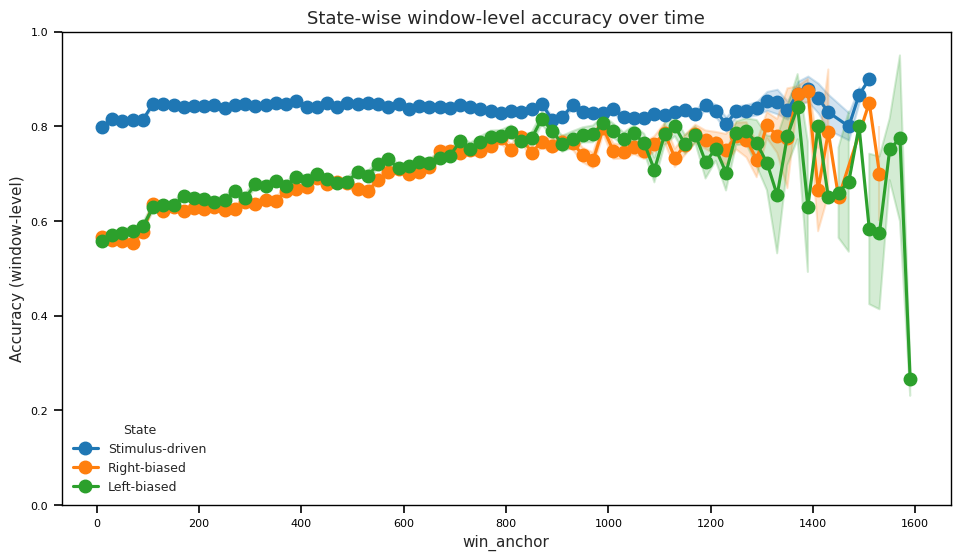

In [48]:
def plot_statewise_window_accuracy_over_time(
    win_with_acc: pd.DataFrame,
    state_id_to_name: dict,
    bin_size: int = 20,
    anchor_col: str = "win_anchor",
    state_col: str = "state",
    pcol: str = "p_correct_win",
    order_states=None,
    name_palette=None,
):
    """
    Plot state-wise window-level accuracy over raw trial time.
    Mean and SEM is computed across windows within each time bin and state.
    """
    df_acc = win_with_acc.copy()

    # Keep only usable rows
    df_acc[pcol] = pd.to_numeric(df_acc[pcol], errors="coerce")
    df_acc[anchor_col] = pd.to_numeric(df_acc[anchor_col], errors="coerce")
    df_acc[state_col] = pd.to_numeric(df_acc[state_col], errors="coerce")

    df_acc = df_acc.dropna(subset=[pcol, anchor_col, state_col]).copy()
    df_acc[anchor_col] = df_acc[anchor_col].astype(int)
    df_acc[state_col] = df_acc[state_col].astype(int)

    # Canonical state names
    df_acc["state_name"] = df_acc[state_col].map(state_id_to_name)
    df_acc = df_acc.dropna(subset=["state_name"]).copy()

    # Time binning
    df_acc["time_bin"] = (df_acc[anchor_col] // bin_size).astype(int)

    # Summary across windows
    time_state_acc = (
        df_acc.groupby(["time_bin", "state_name"], observed=True)[pcol]
        .agg(
            p_correct="mean",
            sem=sem_safe,
            n_windows="size",
        )
        .reset_index()
    )

    time_bins_sorted = np.sort(time_state_acc["time_bin"].unique())
    center_map = {tb: (tb + 0.5) * bin_size for tb in time_bins_sorted}
    time_state_acc["bin_center"] = time_state_acc["time_bin"].map(center_map)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    states_iter = order_states if order_states is not None else sorted(time_state_acc["state_name"].unique())

    for state in states_iter:
        sub = time_state_acc[time_state_acc["state_name"] == state].sort_values("time_bin")
        if sub.empty:
            continue

        x = sub["bin_center"].to_numpy()
        y = sub["p_correct"].to_numpy()
        se = sub["sem"].to_numpy()
        color = name_palette.get(state, None) if isinstance(name_palette, dict) else None

        ax.plot(x, y, marker="o", label=state, color=color)
        ax.fill_between(x, y - se, y + se, color=color, alpha=0.20)

    ax.set_xlabel("win_anchor", fontsize=11)
    ax.set_ylabel("Accuracy (window-level)", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title("State-wise window-level accuracy over time", fontsize=13)
    ax.legend(title="State", frameon=False, fontsize=9, title_fontsize=9)

    # Styling
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.tick_params(colors="black")
    make_ticks_visible(ax, labelsize=8, length=6, width=1.2)

    plt.tight_layout()
    plt.show()

    return time_state_acc

time_state_acc = plot_statewise_window_accuracy_over_time(
    win_with_acc=win_with_acc,
    state_id_to_name=state_names,
    bin_size=BIN_SIZE,
    anchor_col="win_anchor",
    state_col="state",
    pcol="p_correct_win",
    order_states=order_states,      # state order
    name_palette=name_palette,      # state color
)